# write_data — IoU Scoring + Figure 3 + Figure 4
Scores golden_programs (144 GPT-2-based) against BERT, GPT-2, TinyLlama, Llama-3B.
Produces: `iou_scores_{model}.csv`, `best_fits_{model}.csv`, Figure 3 box plots, Figure 4 heatmaps.

In [ ]:
# ── 0. Install & local setup ───────────────────────────────────────────
# If running on Colab, set `DRIVE_MODE = True` and uncomment the mount lines below.
# Otherwise this notebook expects `data/` and `results/` to be present in the repo root.
# !pip install -q torch transformers spacy nltk tqdm huggingface-hub openai

import os, sys, pathlib

REPO_ROOT = os.path.abspath(os.path.join('..'))  # repo root when running from `code/`
DRIVE_MODE = False
if DRIVE_MODE:
    # Colab mode (manual):
    # from google.colab import drive
    # drive.mount('/content/drive', force_remount=True)
    # DRIVE_ROOT  = '/content/drive/MyDrive/LLM-Interpretability'
    # DATA_DIR    = f'{DRIVE_ROOT}/data'
    # RESULTS_DIR = f'{DRIVE_ROOT}/results'
    pass
else:
    DATA_DIR    = os.path.join(REPO_ROOT, 'data')
    RESULTS_DIR = os.path.join(REPO_ROOT, 'results')

os.makedirs(RESULTS_DIR, exist_ok=True)
print(f'DATA_DIR={DATA_DIR}')
print(f'RESULTS_DIR={RESULTS_DIR}')

Mounted at /content/drive


In [ ]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import inspect, re, random, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import seaborn as sns
from tqdm import tqdm
from transformers import AutoModel, AutoTokenizer
warnings.filterwarnings('ignore')

RANDOM_SEED = 42
random.seed(RANDOM_SEED); np.random.seed(RANDOM_SEED); torch.manual_seed(RANDOM_SEED)
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

Device: cuda


In [ ]:
# ── 2. HuggingFace login (for gated models) ───────────────────────────────────
from huggingface_hub import login
import os
hf_token = os.environ.get('HF_TOKEN')
if hf_token:
    login(token=hf_token)
else:
    print('No HF_TOKEN env var found; set HF_TOKEN or set per-model hf_token in MODEL_CONFIGS if required.')

In [ ]:
# ── 3. Load programs — one per model from {model}_programs.py ────────────────
# Each model uses only its own programs. Files: gpt2_programs.py,
# bert_programs.py, tinyllama_programs.py, llama3b_programs.py
# Place all in DRIVE_ROOT/data/ alongside golden_programs.py

import importlib.util, sys

HELPERS = {
    'get_nlp', '_get_gpt2_tokenizer', 'gpt2_tokenize', 'spacy_parse',
    'align_spacy_to_gpt2', 'align_gpt2_to_spacy', 'make_row_stochastic',
    'apply_causal_mask', 'get_modifying_adjectives'
}

def load_programs_for_model(model_key):
    prog_file = f'{DATA_DIR}/{model_key}_programs.py'
    if not os.path.exists(prog_file):
        print(f'[WARN] {prog_file} not found — skipping {model_key}')
        return []
    spec = importlib.util.spec_from_file_location(f'{model_key}_programs', prog_file)
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    progs = [
        obj for _, obj in inspect.getmembers(mod, inspect.isfunction)
        if re.search(r'_[Ll]\d+[Hh]\d+$', obj.__name__)  # only L#H# programs
    ]
    return progs

# Load per-model program sets
MODEL_PROGRAMS = {}
for mk in ['bert', 'gpt2', 'tinyllama', 'llama3b']:
    progs = load_programs_for_model(mk)
    MODEL_PROGRAMS[mk] = progs
    print(f'{mk:12s}: {len(progs)} programs loaded')

# Helper: intended head map for GPT-2 (programs ending in _L#H#)
def parse_intended_head(name):
    m = re.search(r'_[Ll](\d+)[Hh](\d+)$', name)
    return (int(m.group(1)), int(m.group(2))) if m else None

print("\nMappings:")
INTENDED_MAPS = {}
for mk, progs in MODEL_PROGRAMS.items():
    imap = {}
    for f in progs:
        lh = parse_intended_head(f.__name__)
        if lh is not None:
            imap[lh] = f
    INTENDED_MAPS[mk] = imap
    print(f'{mk:12s}: {len(imap)} intended head mappings')

INTENDED_MAP_GPT2 = INTENDED_MAPS.get('gpt2', {})  # keep for backward compat

bert        : 144 programs loaded
gpt2        : 144 programs loaded
tinyllama   : 704 programs loaded
llama3b     : 672 programs loaded

Mappings:
bert        : 144 intended head mappings
gpt2        : 144 intended head mappings
tinyllama   : 704 intended head mappings
llama3b     : 672 intended head mappings


In [ ]:
# ── 4. Sentences ──────────────────────────────────────────────────────────────
df_json = pd.read_json(f'{DATA_DIR}/generic_sentences.json')
ALL_SENTENCES = df_json[0].tolist()
_rng = random.Random(RANDOM_SEED)
_shuf = ALL_SENTENCES[:]
_rng.shuffle(_shuf)
SAMPLE_SENTENCES = _shuf[:5]
print(f'Using {len(SAMPLE_SENTENCES)} sentences for scoring')

Using 5 sentences for scoring


In [ ]:
# ── 5. Model configs ──────────────────────────────────────────────────────────
MODEL_CONFIGS = {
    'bert': {
        'display':  'BERT-BASE',
        'hf_name':  'bert-base-uncased',
        'fp16':     False,
        'hf_token': None,
    },
    'gpt2': {
        'display':  'GPT-2',
        'hf_name':  'openai-community/gpt2',
        'fp16':     False,
        'hf_token': None,
    },
    'tinyllama': {
        'display':  'TinyLlama',
        'hf_name':  'TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T',
        'fp16':     True,
        'hf_token': None,
    },
    'llama3b': {
        'display':  'Llama-3.2-3B',
        'hf_name':  'meta-llama/Llama-3.2-3B',
        'fp16':     True,
        'hf_token': None,  # uses global login above
    },
}

In [ ]:
# ── 6. Scoring helpers ────────────────────────────────────────────────────────
def iou_score(p, q):
    p = np.clip(p.astype(np.float64), 1e-12, 1.0)
    q = np.clip(q.astype(np.float64), 1e-12, 1.0)
    return float(np.minimum(p, q).sum() / np.maximum(p, q).sum())

def load_model(cfg):
    kw = dict(output_attentions=True, attn_implementation='eager')
    if cfg['fp16']:    kw['torch_dtype'] = torch.float16
    if cfg['hf_token']: kw['token'] = cfg['hf_token']
    model = AutoModel.from_pretrained(cfg['hf_name'], **kw).to(DEVICE).eval()
    tok_kw = {'token': cfg['hf_token']} if cfg['hf_token'] else {}
    tok = AutoTokenizer.from_pretrained(cfg['hf_name'], **tok_kw)
    if tok.pad_token is None:
        tok.pad_token = tok.eos_token
    return model, tok

def get_attention_cache(model, tok, sentences, device):
    """One forward pass per sentence, cache all layer x head attention tensors."""
    cache = []  # list of dicts: sentence -> {(layer, head): np.ndarray}
    for sent in sentences:
        inputs = tok(sent, return_tensors='pt', truncation=True, max_length=512).to(device)
        with torch.no_grad():
            out = model(**inputs)
        sent_cache = {}
        for l, attn in enumerate(out.attentions):
            attn_np = attn[0].to(torch.float32).cpu().numpy()  # (n_heads, seq, seq)
            n_heads = attn_np.shape[0]
            for h in range(n_heads):
                sent_cache[(l, h)] = attn_np[h]  # (seq, seq)
        cache.append(sent_cache)
    return cache

def get_program_matrix(prog, sent, tok, target_n):
    try:
        result = prog(sent, tok)
        if isinstance(result, tuple):
            result = result[1]
        result = np.array(result, dtype=np.float64)
        if result.ndim != 2 or result.shape[0] != result.shape[1]:
            return None
        if result.shape[0] != target_n:
            return None
        result = np.clip(result, 0, None)
        row_sums = result.sum(axis=1, keepdims=True)
        row_sums[row_sums == 0] = 1.0
        return result / row_sums
    except Exception:
        return None

In [ ]:
# ── 7. Main scoring loop → iou_scores_{model}.csv ────────────────────────────
# Each model is scored against its own program set from MODEL_PROGRAMS.
# Caching: 1 forward pass per sentence; program matrices cached per (prog, sent).

for model_key, cfg in MODEL_CONFIGS.items():
    out_path = f'{RESULTS_DIR}/iou_scores_{model_key}.csv'
    if os.path.exists(out_path):
        print(f'[SKIP] {model_key}: already exists')
        continue

    model_progs = MODEL_PROGRAMS.get(model_key, [])
    if not model_progs:
        print(f'[SKIP] {model_key}: no programs loaded')
        continue

    print(f'\n[INFO] Scoring {model_key} ({cfg["display"]}) with {len(model_progs)} programs')
    model, tok = load_model(cfg)
    n_layers = model.config.num_hidden_layers
    n_heads  = model.config.num_attention_heads
    print(f'  Layers={n_layers}, Heads/layer={n_heads}')

    print('  Caching attention maps...')
    attn_cache = get_attention_cache(model, tok, SAMPLE_SENTENCES, DEVICE)

    print('  Caching program matrices...')
    prog_cache = {}
    for pi, prog in enumerate(model_progs):
        for si, sent in enumerate(SAMPLE_SENTENCES):
            n = attn_cache[si][(0, 0)].shape[0]
            mat = get_program_matrix(prog, sent, tok, n)
            prog_cache[(pi, si)] = mat

    print('  Scoring...')
    rows = []
    for l in tqdm(range(n_layers), desc=f'  {model_key} layers'):
        for h in range(n_heads):
            for pi, prog in enumerate(model_progs):
                scores = []
                for si in range(len(SAMPLE_SENTENCES)):
                    a = attn_cache[si][(l, h)]
                    p = prog_cache[(pi, si)]
                    if p is None or p.shape != a.shape:
                        continue
                    scores.append(iou_score(a, p))
                if scores:
                    rows.append({
                        'layer': l, 'head': h,
                        'program_idx': pi,
                        'program_name': prog.__name__,
                        'iou_score': float(np.mean(scores))
                    })

    df = pd.DataFrame(rows)
    df.to_csv(out_path, index=False)
    print(f'  Saved {len(df)} rows → {out_path}')

    del model, tok, attn_cache, prog_cache
    torch.cuda.empty_cache()

print('\n[DONE] All models scored.')

[SKIP] bert: already exists
[SKIP] gpt2: already exists
[SKIP] tinyllama: already exists
[SKIP] llama3b: already exists

[DONE] All models scored.


In [ ]:
# ── 8. Build best_fits_{model}.csv ───────────────────────────────────────────
# For each (layer, head): best program across all programs.
# For GPT-2 only: also store the intended program score.

for model_key, cfg in MODEL_CONFIGS.items():
    iou_path = f'{RESULTS_DIR}/iou_scores_{model_key}.csv'
    out_path  = f'{RESULTS_DIR}/best_fits_{model_key}.csv'

    if not os.path.exists(iou_path):
        print(f'[WARN] Missing {iou_path}, skipping')
        continue

    df = pd.read_csv(iou_path)
    best = (
        df.sort_values('iou_score', ascending=False)
          .groupby(['layer', 'head'], as_index=False)
          .first()
          .rename(columns={'iou_score': 'best_iou', 'program_name': 'best_program'})
    )

    if model_key == 'gpt2':
        # Add intended program score for GPT-2
        intended_rows = []
        for (l, h), prog in INTENDED_MAP_GPT2.items():
            row = df[(df.layer == l) & (df.head == h) & (df.program_name == prog.__name__)]
            score = float(row['iou_score'].values[0]) if len(row) else np.nan
            intended_rows.append({'layer': l, 'head': h,
                                   'intended_program': prog.__name__,
                                   'intended_iou': score})
        df_int = pd.DataFrame(intended_rows)
        best = best.merge(df_int, on=['layer', 'head'], how='left')

    best.to_csv(out_path, index=False)
    print(f'[{model_key}] best_fits saved → {out_path}  ({len(best)} heads)')

print('\n[DONE] best_fits CSVs built.')

[bert] best_fits saved → /content/drive/MyDrive/LLM-Interpretability/results/best_fits_bert.csv  (144 heads)
[gpt2] best_fits saved → /content/drive/MyDrive/LLM-Interpretability/results/best_fits_gpt2.csv  (144 heads)
[tinyllama] best_fits saved → /content/drive/MyDrive/LLM-Interpretability/results/best_fits_tinyllama.csv  (704 heads)
[llama3b] best_fits saved → /content/drive/MyDrive/LLM-Interpretability/results/best_fits_llama3b.csv  (672 heads)

[DONE] best_fits CSVs built.


In [ ]:
# ── 9. Compute baselines (random token, random column, lower diagonal) ────────
# One pass per model — loads model briefly just for attention shapes.

def compute_baselines_for_model(cfg, sentences, device):
    model, tok = load_model(cfg)
    n_layers = model.config.num_hidden_layers
    n_heads  = model.config.num_attention_heads
    cache = get_attention_cache(model, tok, sentences, device)
    del model
    torch.cuda.empty_cache()

    token_ious, col_ious, diag_ious = [], [], []
    for l in range(n_layers):
        for h in range(n_heads):
            for si in range(len(sentences)):
                a = cache[si][(l, h)]
                n = a.shape[0]

                # Random token: one-hot random column per row
                rt = np.zeros_like(a)
                cols = np.random.randint(0, n, size=n)
                rt[np.arange(n), cols] = 1.0
                token_ious.append(iou_score(a, rt))

                # Random column: uniform over random column
                rc = np.zeros_like(a)
                c = np.random.randint(0, n)
                rc[:, c] = 1.0 / n
                col_ious.append(iou_score(a, rc))

                # Lower diagonal (causal mask)
                ld = np.tril(np.ones((n, n)))
                ld = ld / (ld.sum(axis=1, keepdims=True) + 1e-12)
                diag_ious.append(iou_score(a, ld))

    return np.array(token_ious) * 100, np.array(col_ious) * 100, np.array(diag_ious) * 100


baselines = {}
for model_key, cfg in MODEL_CONFIGS.items():
    bl_path = f'{RESULTS_DIR}/baselines_{model_key}.npz'
    if os.path.exists(bl_path):
        d = np.load(bl_path)
        baselines[model_key] = (d['token'], d['col'], d['diag'])
        print(f'[SKIP] {model_key} baselines already cached')
        continue
    print(f'[INFO] Computing baselines for {model_key}')
    t, c, d = compute_baselines_for_model(cfg, SAMPLE_SENTENCES, DEVICE)
    baselines[model_key] = (t, c, d)
    np.savez(bl_path, token=t, col=c, diag=d)
    print(f'  Saved → {bl_path}')

print('[DONE] Baselines ready.')

[SKIP] bert baselines already cached
[SKIP] gpt2 baselines already cached
[SKIP] tinyllama baselines already cached
[SKIP] llama3b baselines already cached
[DONE] Baselines ready.


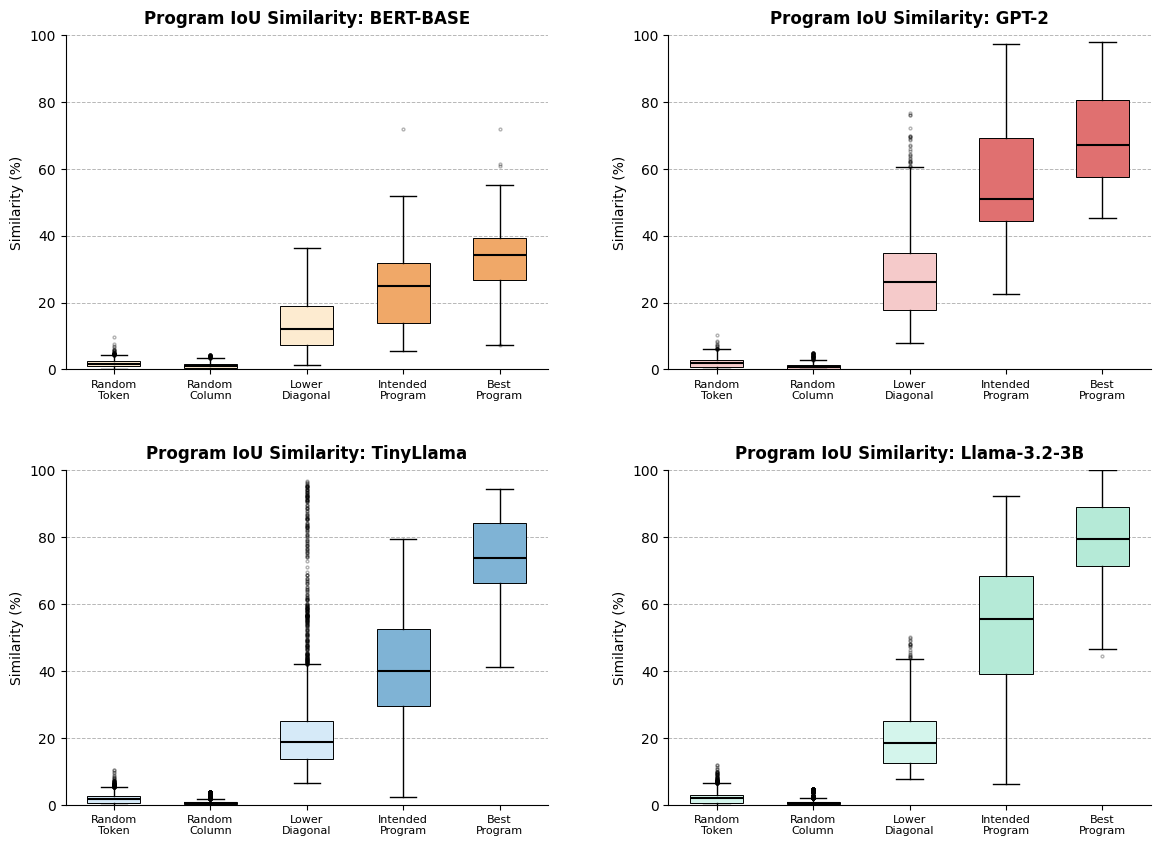

[DONE] Figure 3 saved.


In [ ]:
# ── 10. FIGURE 3 — Box plots ─────────────────────────────────────────────────
# All models: Random Token | Random Column | Lower Diagonal | Intended Program | Best Program
# Intended = program whose name ends in _L{layer}H{head} for that head
# Best     = max IoU program across all programs for that head

import re

ROW_COLORS = {
    'bert':      {'base': '#fdebd0', 'box': '#f0a868'},
    'gpt2':      {'base': '#f5caca', 'box': '#e07070'},
    'tinyllama': {'base': '#d6eaf8', 'box': '#7fb3d5'},
    'llama3b':   {'base': '#d4f5ec', 'box': '#b5ead7'},
}

LABELS_5 = ['Random\nToken', 'Random\nColumn', 'Lower\nDiagonal',
             'Intended\nProgram', 'Best\nProgram']

def styled_boxplot(ax, data_list, labels, colors):
    valid = [(d, l, c, i+1) for i, (d, l, c) in
             enumerate(zip(data_list, labels, colors)) if len(d) > 0]
    if not valid: return
    vdata, vlabels, vcolors, vpos = zip(*valid)
    bp = ax.boxplot(list(vdata), positions=list(vpos), patch_artist=True, widths=0.55,
                    medianprops=dict(color='black', linewidth=1.5),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3),
                    whiskerprops=dict(linewidth=1.0),
                    capprops=dict(linewidth=1.0))
    for patch, color in zip(bp['boxes'], vcolors):
        patch.set_facecolor(color); patch.set_edgecolor('black'); patch.set_linewidth(0.7)
    ax.set_xticks(list(vpos))
    ax.set_xticklabels(list(vlabels), fontsize=8, ha='center')

def get_intended_ious(iou_df):
    """For each (layer, head), find the score of the program ending in _L{layer}H{head}."""
    intended = []
    for (l, h), grp in iou_df.groupby(['layer', 'head']):
        pattern = re.compile(rf'_[Ll]{l}[Hh]{h}$')
        match = grp[grp.program_name.str.contains(pattern, regex=True)]
        if len(match):
            intended.append(float(match.iou_score.values[0]) * 100)
    return intended

keys = ['bert', 'gpt2', 'tinyllama', 'llama3b']
fig = plt.figure(figsize=(14, 10))
gs  = fig.add_gridspec(2, 2, hspace=0.3, wspace=0.25)

for idx, model_key in enumerate(keys):
    ax  = fig.add_subplot(gs[idx // 2, idx % 2])
    cfg = MODEL_CONFIGS[model_key]
    c   = ROW_COLORS[model_key]

    iou_path = f'{RESULTS_DIR}/iou_scores_{model_key}.csv'
    if not os.path.exists(iou_path) or model_key not in baselines:
        ax.set_title(f'Program IoU Similarity: {cfg["display"]}', fontweight='bold', pad=8)
        ax.set_xticks(range(1, 6))
        ax.set_xticklabels(LABELS_5, fontsize=8)
        ax.text(0.5, 0.5, 'scoring in progress...', ha='center', va='center',
                transform=ax.transAxes, fontsize=11, color='gray', style='italic')
        ax.set_ylim(0, 100)
        ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
        continue

    iou_df = pd.read_csv(iou_path)
    best_ious     = (iou_df.groupby(['layer','head'])['iou_score'].max().values * 100).tolist()
    intended_ious = get_intended_ious(iou_df)
    t_bl, c_bl, d_bl = baselines[model_key]

    data_list = [t_bl.tolist(), c_bl.tolist(), d_bl.tolist(), intended_ious, best_ious]
    colors    = [c['base'], c['base'], c['base'], c['box'], c['box']]

    styled_boxplot(ax, data_list, LABELS_5, colors)
    ax.set_title(f'Program IoU Similarity: {cfg["display"]}', fontweight='bold', pad=8)
    ax.set_ylabel('Similarity (%)')
    ax.set_ylim(0, 100)
    ax.grid(True, axis='y', linestyle='--', linewidth=0.7, alpha=0.9)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# fig.suptitle('Program IoU Similarity Across Models', fontsize=13, fontweight='bold', y=1.01)
plt.savefig(f'{RESULTS_DIR}/figure_4_1.pdf', bbox_inches='tight', dpi=150)
plt.savefig(f'{RESULTS_DIR}/figure_3_boxplots.png', bbox_inches='tight', dpi=150)
plt.show()
print('[DONE] Figure 3 saved.')

In [ ]:
# ── 10.5. Auto-categorize programs per model → {model}_program_categories.json ──
# For each model that has programs loaded, checks if a categories file exists.
# If not, calls GPT-4o to categorize each program function into one of six
# semantic categories based on its source code. Saves per-model JSON.
# Cell 11 loads these files for heatmap coloring.

import json
import inspect
import time
from openai import OpenAI
import os

OPENAI_KEY = os.environ.get('OPENAI_API_KEY')
if OPENAI_KEY:
    _oai_client = OpenAI(api_key=OPENAI_KEY)
else:
    _oai_client = None
    print('No OPENAI_API_KEY found; auto-categorization will be skipped. Set OPENAI_API_KEY to enable it.')

CATEGORIES = [
    'initiation_and_anchoring',       # first token, sentence start, CLS emphasis
    'relational_and_semantic',         # coreference, semantic similarity, entity tracking
    'special_tokens_and_boundaries',   # punctuation, clause boundaries, separators
    'linguistic_and_syntactic',        # POS, dependency, syntactic structure
    'sequential_and_induction',        # previous token, next token, induction, copying
    'uniformity_and_global',           # uniform attention, lower diagonal, global patterns
]

CATEGORY_PROMPT = """You are categorizing transformer attention head programs for interpretability research.

Given the following Python function that approximates an attention head, assign it to exactly ONE category from this list:
- initiation_and_anchoring: focuses on first token, sentence start, CLS token, or anchoring to initial elements
- relational_and_semantic: coreference, semantic similarity, named entity tracking, content word relations
- special_tokens_and_boundaries: punctuation, clause/sentence boundaries, separator tokens
- linguistic_and_syntactic: POS tags, dependency structure, syntactic roles (subject, verb, object)
- sequential_and_induction: previous token, next token, induction heads, local copying behavior
- uniformity_and_global: uniform attention, lower diagonal, position-based decay, broad/global patterns

Respond with ONLY the category name, nothing else.

Function:
{code}
"""

def categorize_program(func) -> str:
    """Call GPT-4o to categorize a single program function. Returns category string."""
    try:
        code = inspect.getsource(func)
    except Exception:
        return 'uniformity_and_global'
    if _oai_client is None:
        return 'uniformity_and_global'

    for attempt in range(3):
        try:
            resp = _oai_client.chat.completions.create(
                model='gpt-4o',
                messages=[{'role': 'user', 'content': CATEGORY_PROMPT.format(code=code[:3000])}],
                max_tokens=20,
                temperature=0.0,
            )
            result = resp.choices[0].message.content.strip().lower().replace(' ', '_').replace('-', '_')
            if result in CATEGORIES:
                return result
            # fuzzy match — pick closest
            for cat in CATEGORIES:
                if any(kw in result for kw in cat.split('_')):
                    return cat
            return 'uniformity_and_global'
        except Exception as e:
            if attempt == 2:
                print(f'    [WARN] GPT error for {func.__name__}: {e}')
                return 'uniformity_and_global'
            time.sleep(2 ** attempt)
    return 'uniformity_and_global'


MODEL_PROGRAM_CATEGORIES = {}

for model_key, progs in MODEL_PROGRAMS.items():
    if not progs:
        print(f'[SKIP] {model_key}: no programs')
        continue

    cat_path = f'{RESULTS_DIR}/{model_key}_program_categories.json'

    if os.path.exists(cat_path):
        with open(cat_path) as f:
            MODEL_PROGRAM_CATEGORIES[model_key] = json.load(f)
        total = sum(len(v) for v in MODEL_PROGRAM_CATEGORIES[model_key].values())
        print(f'[LOAD] {model_key}: {total} programs categorized from {cat_path}')
        continue

    print(f'\n[INFO] Categorizing {len(progs)} programs for {model_key} via GPT-4o...')
    cats = {c: [] for c in CATEGORIES}
    n = len(progs)

    for i, prog in enumerate(progs):
        cat = categorize_program(prog)
        cats[cat].append(prog.__name__)
        if (i + 1) % 10 == 0 or (i + 1) == n:
            print(f'  {i+1}/{n} categorized...')

    MODEL_PROGRAM_CATEGORIES[model_key] = cats
    with open(cat_path, 'w') as f:
        json.dump(cats, f, indent=2)
    print(f'  Saved → {cat_path}')
    for cat, names in cats.items():
        if names:
            print(f'    {cat}: {len(names)}')


# Build flat lookup: model_key -> {prog_name: category}
PROG_TO_CAT_BY_MODEL = {}
for model_key, cats in MODEL_PROGRAM_CATEGORIES.items():
    PROG_TO_CAT_BY_MODEL[model_key] = {
        name: cat
        for cat, names in cats.items()
        for name in names
    }

print('\n[DONE] Program categories ready.')
print('PROG_TO_CAT_BY_MODEL keys:', list(PROG_TO_CAT_BY_MODEL.keys()))

[LOAD] bert: 144 programs categorized from /content/drive/MyDrive/LLM-Interpretability/results/bert_program_categories.json
[LOAD] gpt2: 144 programs categorized from /content/drive/MyDrive/LLM-Interpretability/results/gpt2_program_categories.json
[LOAD] tinyllama: 704 programs categorized from /content/drive/MyDrive/LLM-Interpretability/results/tinyllama_program_categories.json
[LOAD] llama3b: 672 programs categorized from /content/drive/MyDrive/LLM-Interpretability/results/llama3b_program_categories.json

[DONE] Program categories ready.
PROG_TO_CAT_BY_MODEL keys: ['bert', 'gpt2', 'tinyllama', 'llama3b']


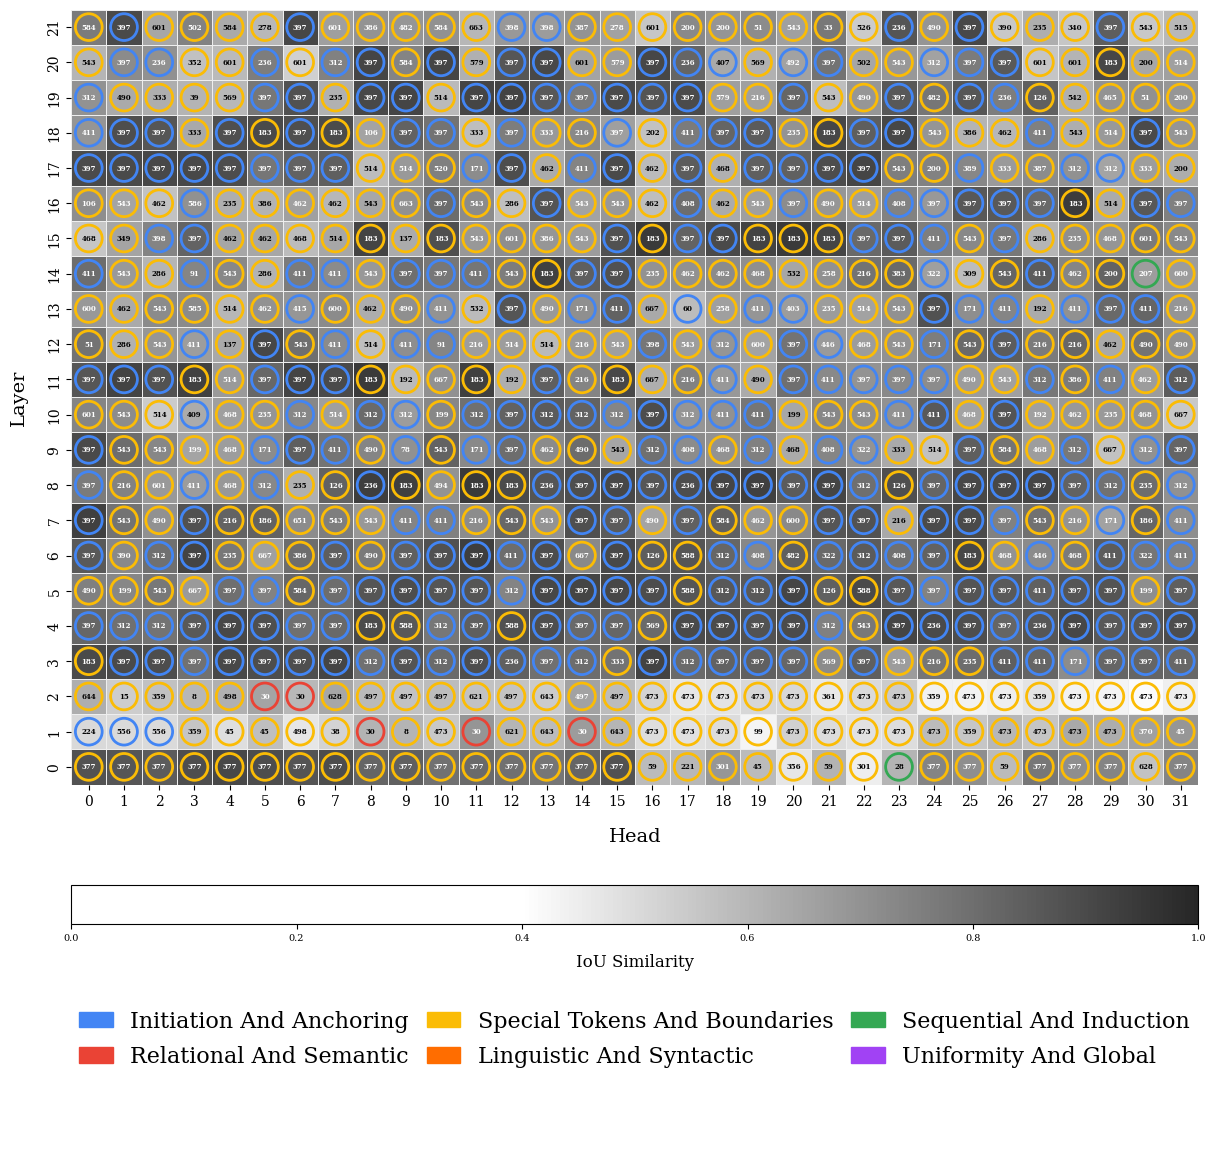

In [ ]:
# ── 11. FIGURE 4 — Heatmaps (one per model) ───────────────────────────────────
# Circle number = index of best-fit program in MODEL_PROGRAMS[model_key].
# Circle color  = program category from PROG_TO_CAT_BY_MODEL.
# Colorbar shows IoU similarity scale. Category legend 3x2 below.

import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import matplotlib.colorbar as mcolorbar
import seaborn as sns

CATEGORY_COLORS = {
    'initiation_and_anchoring':      '#4285F4',
    'relational_and_semantic':       '#EA4335',
    'special_tokens_and_boundaries': '#FBBC05',
    'linguistic_and_syntactic':      '#FF6D00',
    'sequential_and_induction':      '#34A853',
    'uniformity_and_global':         '#A142F4',
}

HEATMAP_CMAP = mcolors.LinearSegmentedColormap.from_list(
    'custom_gray',
    list(zip([0.0, 0.4, 1.0], [(1,1,1), (1,1,1), (0.15,0.15,0.15)]))
)

def get_cat_for_model(model_key, prog_name):
    return PROG_TO_CAT_BY_MODEL.get(model_key, {}).get(prog_name, 'uniformity_and_global')

def get_text_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    return 'black' if (0.2126*r + 0.7152*g + 0.0722*b) > 0.5 else 'white'

def get_prog_index(prog_name, model_key):
    """1-based index of prog_name in MODEL_PROGRAMS[model_key], 0 if not found."""
    for i, p in enumerate(MODEL_PROGRAMS.get(model_key, [])):
        if p.__name__ == prog_name:
            return i + 1
    return 0

def plot_heatmap(model_key, cfg):
    bf_path = f'{RESULTS_DIR}/best_fits_{model_key}.csv'
    if not os.path.exists(bf_path):
        print(f'[SKIP] {model_key} — best_fits not found')
        return

    bf = pd.read_csv(bf_path)
    n_layers = int(bf['layer'].max()) + 1
    n_heads  = int(bf['head'].max()) + 1

    score_mat = np.zeros((n_layers, n_heads))
    name_mat  = np.full((n_layers, n_heads), '', dtype=object)
    for _, row in bf.iterrows():
        l, h = int(row['layer']), int(row['head'])
        score_mat[l, h] = row['best_iou'] if not pd.isna(row['best_iou']) else 0.0
        name_mat[l, h]  = str(row['best_program']) if 'best_program' in row else ''

    cell  = 0.5
    fig_w = n_heads * cell + 2.5
    fig_h = n_layers * cell + 4.5
    fig = plt.figure(figsize=(fig_w, fig_h))

    gs = fig.add_gridspec(1, 1, left=0.15, right=0.85, top=0.9, bottom=0.4)
    ax = fig.add_subplot(gs[0])

    sns.heatmap(score_mat, ax=ax, cmap=HEATMAP_CMAP, cbar=False,
                linewidths=0.4, linecolor='#EEEEEE',
                vmin=0, vmax=1, square=True)

    label_fontsize = max(4, 7 - n_heads // 16)

    for l in range(n_layers):
        for h in range(n_heads):
            name = name_mat[l, h]
            if not name: continue
            cat   = get_cat_for_model(model_key, name)
            color = CATEGORY_COLORS.get(cat, '#888888')
            idx   = get_prog_index(name, model_key)

            ax.add_patch(plt.Circle(
                (h + 0.5, l + 0.5), radius=0.38,
                facecolor='none', edgecolor=color,
                linewidth=2.0, zorder=3))

            # text color based on heatmap cell brightness, not circle color
            bg_val  = score_mat[l, h]
            tc = 'white' if bg_val > 0.65 else 'black'
            ax.text(h + 0.5, l + 0.5, str(idx),
                    ha='center', va='center',
                    fontsize=label_fontsize,
                    color=tc, fontweight='bold', zorder=4)

    ax.invert_yaxis()
    ax.set_ylim(0, n_layers)
    ax.set_xlabel('Head', fontsize=14, labelpad=14)
    ax.set_ylabel('Layer', fontsize=14, labelpad=14)
    # ax.set_title(f'Program IoU Similarity: {cfg["display"]}',
                #  fontweight='bold', fontsize=12, pad=20)

    plt.draw()
    pos = ax.get_position()

    # ── Colorbar — full heatmap width ────────────────────────────────────────
    cbar_ax = fig.add_axes([pos.x0, pos.y0 - 0.09, pos.width, 0.025])
    sm = plt.cm.ScalarMappable(cmap=HEATMAP_CMAP, norm=mcolors.Normalize(vmin=0, vmax=1))
    cb = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
    cb.set_label('IoU Similarity', fontsize=12, labelpad=8)
    cb.ax.tick_params(labelsize=7)

    # ── Legend — full heatmap width, below colorbar ──────────────────────────
    leg_ax = fig.add_axes([pos.x0, pos.y0 - 0.23, pos.width, 0.09])
    leg_ax.axis('off')

    cat_patches = [
        mpatches.Patch(color=v, label=k.replace('_', ' ').title())
        for k, v in CATEGORY_COLORS.items()
    ]
    leg = leg_ax.legend(
        handles=cat_patches,
        loc='upper center',
        ncol=3,
        fontsize=16,
        frameon=False,
        # title='Program Categories',
        title_fontproperties={'weight': 'bold', 'size': 10},
        handlelength=1.5,
        columnspacing=0.8,
        labelspacing=0.6,
        borderaxespad=0.0,
    )
    leg._legend_box.sep = 10

    out = f'{RESULTS_DIR}/figure_4_{model_key}_heatmap'
    plt.savefig(out + '.pdf', bbox_inches='tight', dpi=800)
    plt.show()

for model_key, cfg in MODEL_CONFIGS.items():
    if model_key == "tinyllama":
        plot_heatmap(model_key, cfg)

In [ ]:
# ── 12. Verification summary ──────────────────────────────────────────────────
print('=== IoU Scoring Summary ===')
for model_key in MODEL_CONFIGS:
    p = f'{RESULTS_DIR}/best_fits_{model_key}.csv'
    if os.path.exists(p):
        df = pd.read_csv(p)
        mean_iou = df['best_iou'].mean() * 100
        print(f'  {model_key:12s} | heads={len(df):4d} | mean best IoU={mean_iou:.1f}%')
    else:
        print(f'  {model_key:12s} | MISSING')

=== IoU Scoring Summary ===
  bert         | heads= 144 | mean best IoU=34.0%
  gpt2         | heads= 144 | mean best IoU=69.1%
  tinyllama    | heads= 704 | mean best IoU=74.2%
  llama3b      | heads= 672 | mean best IoU=79.4%


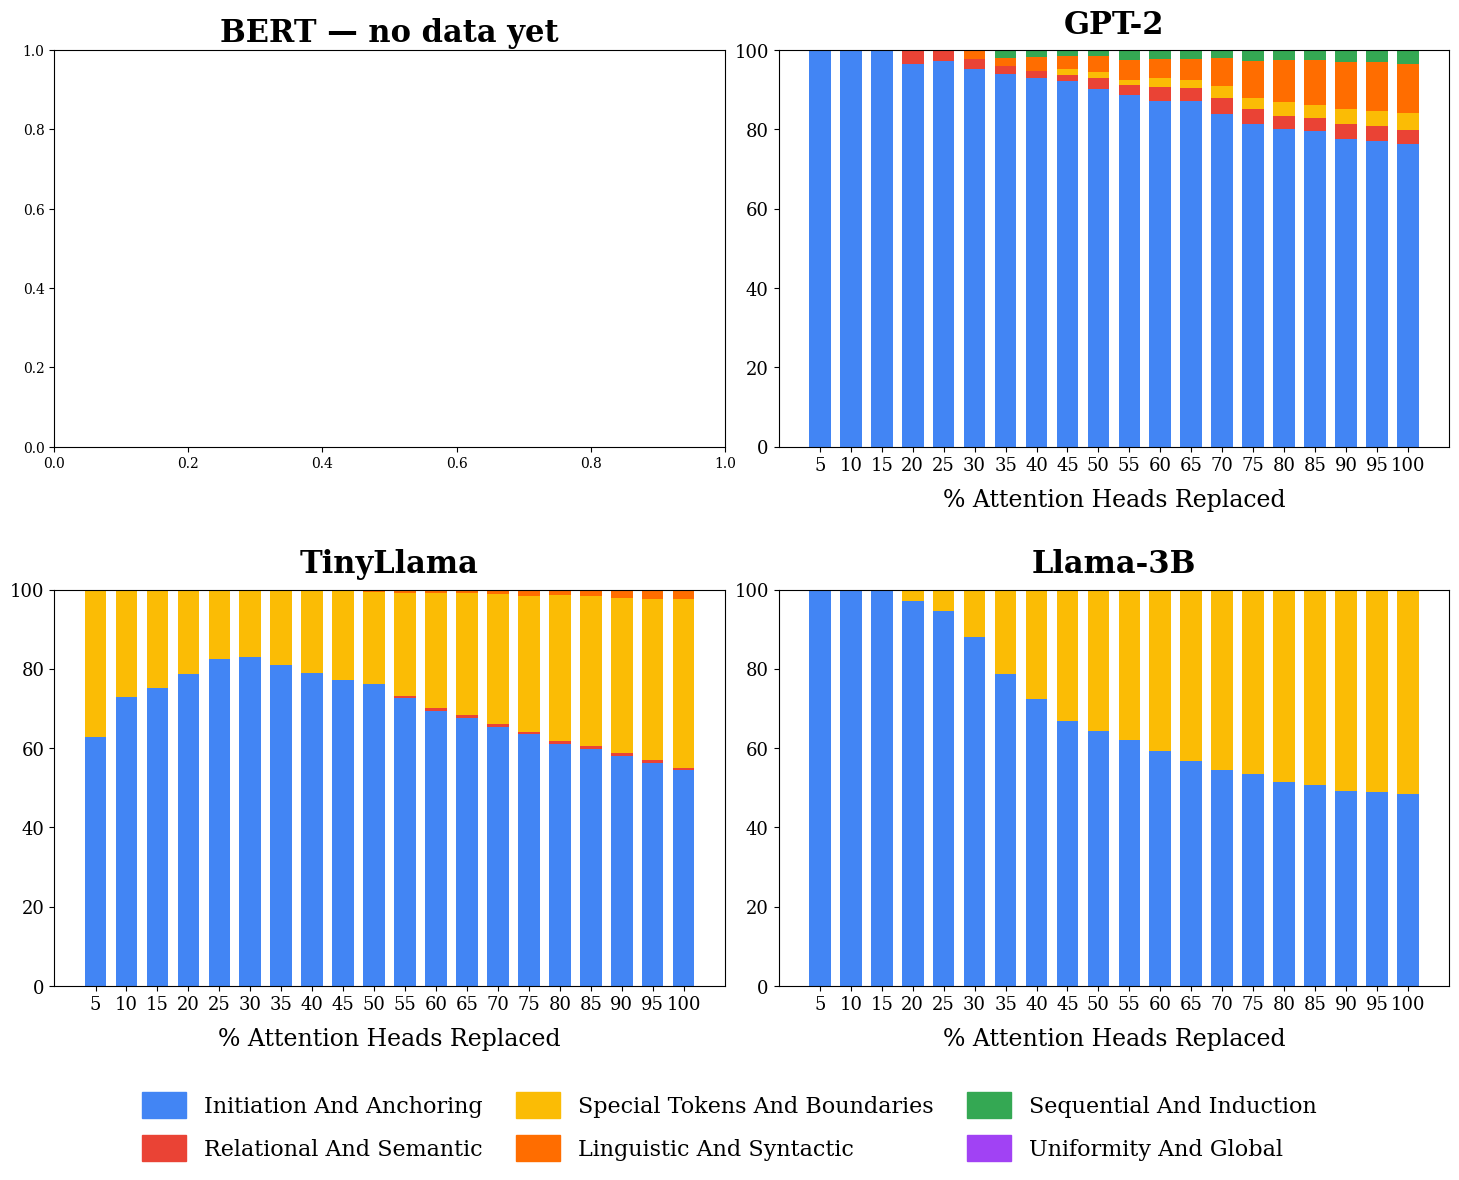

In [ ]:
import matplotlib.patches as mpatches

# ── Load per-model categories ─────────────────────────────────────────────────
PROG_TO_CAT_PLOT = {}
for mk in ['bert', 'gpt2', 'tinyllama', 'llama3b']:
    cat_path = f'{RESULTS_DIR}/{mk}_program_categories.json'
    if os.path.exists(cat_path):
        with open(cat_path) as f:
            cats = json.load(f)
        for cat, progs in cats.items():
            for prog in progs:
                PROG_TO_CAT_PLOT[prog] = cat
    else:
        print(f'[WARN] {cat_path} not found — programs will default to uniformity_and_global')

CATEGORY_COLORS = {
    'initiation_and_anchoring':      '#4285F4',
    'relational_and_semantic':       '#EA4335',
    'special_tokens_and_boundaries': '#FBBC05',
    'linguistic_and_syntactic':      '#FF6D00',
    'sequential_and_induction':      '#34A853',
    'uniformity_and_global':         '#A142F4',
}

PLOT_CONFIG = {
    'BERT':      {'key': 'bert',      'total': 144},
    'GPT-2':     {'key': 'gpt2',      'total': 144},
    'TinyLlama': {'key': 'tinyllama', 'total': 704},
    'Llama-3B':  {'key': 'llama3b',   'total': 672},
}

REPLACEMENT_LEVELS = [round(x * 0.05, 2) for x in range(1, 21)]

def get_category_counts_at_level(df, total_heads, pct):
    n = int(total_heads * pct)
    subset = df.sort_values('k').head(n)
    counts = {cat: 0 for cat in CATEGORY_COLORS}
    for prog in subset['program']:
        cat = PROG_TO_CAT_PLOT.get(prog, 'uniformity_and_global')
        counts[cat] += 1
    return counts

plt.rcParams['font.family'] = 'serif'
fig, axes = plt.subplots(2, 2, figsize=(18, 13))
fig.subplots_adjust(hspace=0.36, wspace=0.08, bottom=0.16)

for ax, (model_name, cfg) in zip(axes.flatten(), PLOT_CONFIG.items()):
    csv_path = f'{RESULTS_DIR}/replacement_run/{cfg["key"]}_smart.csv'
    if not os.path.exists(csv_path):
        ax.set_title(f'{model_name} — no data yet', fontweight='bold', fontsize=22)
        continue

    df    = pd.read_csv(csv_path)
    total = cfg['total']
    x     = [int(p * 100) for p in REPLACEMENT_LEVELS]
    cats  = list(CATEGORY_COLORS.keys())

    bottoms = np.zeros(len(REPLACEMENT_LEVELS))
    for cat in cats:
        heights = np.array([
            get_category_counts_at_level(df, total, pct)[cat] / max(int(total * pct), 1) * 100
            for pct in REPLACEMENT_LEVELS
        ])
        ax.bar(x, heights, bottom=bottoms,
               color=CATEGORY_COLORS[cat], width=3.5)
        bottoms += heights

    ax.set_title(model_name, fontweight='bold', fontsize=22, pad=12)
    ax.set_xlabel('% Attention Heads Replaced', fontsize=17, labelpad=10)
    ax.set_xticks(x)
    ax.tick_params(axis='both', labelsize=13)

legend_patches = [
    mpatches.Patch(color=CATEGORY_COLORS[c], label=c.replace('_', ' ').title())
    for c in CATEGORY_COLORS
]
fig.legend(handles=legend_patches, loc='lower center',
           ncol=3, fontsize=16, frameon=False,
           bbox_to_anchor=(0.5, 0.01),
           handleheight=1.4, handlelength=2.0,
           labelspacing=0.8, columnspacing=1.5)

plt.savefig(f'{RESULTS_DIR}/plots/figure_compositional_dynamics.pdf', bbox_inches='tight')
plt.savefig(f'{RESULTS_DIR}/plots/figure_compositional_dynamics.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 13. Replacement experiment — setup ───────────────────────────────────────
import os, pathlib, ast, copy
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from transformers import (
    GPT2LMHeadModel, GPT2Tokenizer,
    BertForMaskedLM, AutoTokenizer, AutoModelForCausalLM,
    logging as hf_logging
)
hf_logging.set_verbosity_error()
os.makedirs(f'{RESULTS_DIR}/replacement_run', exist_ok=True)

DEVICE_R = "cuda" if torch.cuda.is_available() else "cpu"

def prepare_sentence(sent, mode="last_word"):
    words = sent.split()
    if len(words) <= 3: return sent
    if mode == "last_word": return " ".join(words[:-1])
    if mode == "random":
        return " ".join(words[:np.random.randint(3, len(words))])
    return sent


# ─────────────────────────────────────────────────────────────────────────────
# GPT-2
# ─────────────────────────────────────────────────────────────────────────────
def run_replacement_experiment_gpt2(
    sentences, best_fits_df, all_programs,
    strategy="baseline", max_heads=144, num_sentences=5,
    spike_threshold=100.0, skip_spikes=True, force_all_heads=True, save_file=""
):
    tokenizer = GPT2Tokenizer.from_pretrained("gpt2")
    eval_sentences = sentences[:num_sentences]
    experiment_results, skipped_programs = [], []

    base_model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE_R).eval()
    baseline_ppls, baseline_logits = [], []
    for sent in eval_sentences:
        active = prepare_sentence(sent)
        toks = tokenizer(active, return_tensors="pt").to(DEVICE_R)
        with torch.no_grad():
            out = base_model(**toks, labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:, -1, :])
    del base_model; torch.cuda.empty_cache()
    print(f"GPT-2 baseline mean PPL: {np.mean(baseline_ppls):.2f}")

    unique_heads_mapping, seen_heads = [], set()
    for _, row in best_fits_df.iterrows():
        ht = (int(row["layer"]), int(row["head"]))
        if ht not in seen_heads:
            unique_heads_mapping.append((ht, [str(row["best_program"])]))
            seen_heads.add(ht)

    def make_baseline_hook(lookup):
        def hook(module, inp, out):
            ctx = out[0]; b,s,d = ctx.shape; nh,hd = 12, d//12
            m = ctx.view(b,s,nh,hd).clone()
            mask = torch.tril(torch.ones((s,s), device=DEVICE_R))
            for h in range(nh):
                if (module.layer_id,h) in lookup: m[:,:,h,:] = torch.matmul(mask, m[:,:,h,:])
            return (m.view(b,s,d),)+out[1:]
        return hook

    def make_smart_hook(lookup, progs):
        def hook(module, inp, out):
            ctx = out[0]; b,s,d = ctx.shape; nh,hd = 12, d//12
            m = ctx.view(b,s,nh,hd).clone()
            sent = getattr(module,"_current_sentence",None)
            if sent is None: return out
            for h in range(nh):
                key=(module.layer_id,h)
                if key in lookup:
                    prog=next((p for p in progs if p.__name__==lookup[key]),None)
                    if prog:
                        try:
                            _,mat=prog(sent,tokenizer)
                            if mat is not None:
                                t=torch.tensor(mat).to(DEVICE_R,dtype=m.dtype)
                                m[:,:,h,:]=torch.matmul(t,m[:,:,h,:])
                        except Exception: pass
            return (m.view(b,s,d),)+out[1:]
        return hook

    accepted, k = [], 0
    for candidate in unique_heads_mapping:
        if k >= max_heads: break
        trial = accepted+[candidate]
        lookup = {tuple(map(int,item[0])):item[1][0] for item in trial}
        rel = set(l for l,_ in lookup)
        model_k = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE_R).eval()
        hook_fn = make_baseline_hook(lookup) if strategy=="baseline" else make_smart_hook(lookup,all_programs)
        handles = []
        for l in range(12):
            tgt=model_k.transformer.h[l].attn; tgt.layer_id=l
            if l in rel: handles.append(tgt.register_forward_hook(hook_fn))
        rep_ppls,kl_divs=[],[]
        for i,sent in enumerate(eval_sentences):
            active=prepare_sentence(sent)
            for l in rel: model_k.transformer.h[l].attn._current_sentence=active
            toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
            with torch.no_grad():
                o=model_k(**toks,labels=toks["input_ids"])
                rep_ppls.append(torch.exp(o.loss).item())
                kl_divs.append(F.kl_div(F.log_softmax(o.logits[:,-1,:],dim=-1),F.softmax(baseline_logits[i],dim=-1),reduction="batchmean").item())
        for h in handles: h.remove()
        del model_k; torch.cuda.empty_cache()
        mean_pct=np.mean([(r-b)/b*100 for r,b in zip(rep_ppls,baseline_ppls)])
        marginal=mean_pct-(experiment_results[-1]["increase"] if experiment_results else 0.0)
        if not force_all_heads and mean_pct>1000.0:
            print(f"PPL>1000% ({mean_pct:.1f}%). Stopping."); break
        if skip_spikes and marginal>spike_threshold:
            skipped_programs.append({"head":candidate[0],"program":candidate[1][0],"marginal":marginal})
            print(f"  [SKIP] {candidate[0]} marginal={marginal:.1f}%"); continue
        k+=1; accepted.append(candidate)
        experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":np.mean(kl_divs),"spike":False})
        print(f"k={k:02d} | {candidate[0]} | {candidate[1][0][:35]} | {mean_pct:.3f}%")

    if force_all_heads:
        accepted_set = {item[0] for item in accepted}
        missing = [c for c in unique_heads_mapping if c[0] not in accepted_set]
        print(f"\n[MOP-UP] {len(missing)} heads remaining — forcing now.")
        for candidate in missing:
            trial=accepted+[candidate]
            lookup={tuple(map(int,item[0])):item[1][0] for item in trial}
            rel=set(l for l,_ in lookup)
            model_k=GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE_R).eval()
            hook_fn=make_baseline_hook(lookup) if strategy=="baseline" else make_smart_hook(lookup,all_programs)
            handles=[]
            for l in range(12):
                tgt=model_k.transformer.h[l].attn; tgt.layer_id=l
                if l in rel: handles.append(tgt.register_forward_hook(hook_fn))
            rep_ppls,kl_divs=[],[]
            for i,sent in enumerate(eval_sentences):
                active=prepare_sentence(sent)
                for l in rel: model_k.transformer.h[l].attn._current_sentence=active
                toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
                with torch.no_grad():
                    o=model_k(**toks,labels=toks["input_ids"])
                    rep_ppls.append(torch.exp(o.loss).item())
                    kl_divs.append(F.kl_div(F.log_softmax(o.logits[:,-1,:],dim=-1),F.softmax(baseline_logits[i],dim=-1),reduction="batchmean").item())
            for h in handles: h.remove()
            del model_k; torch.cuda.empty_cache()
            mean_pct=np.mean([(r-b)/b*100 for r,b in zip(rep_ppls,baseline_ppls)])
            k+=1; accepted.append(candidate)
            experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":np.mean(kl_divs),"spike":True})
            print(f"[MOP-UP] k={k:02d} | {candidate[0]} | {mean_pct:.3f}%")

    df_out=pd.DataFrame(experiment_results)
    out_path=save_file or f'{RESULTS_DIR}/replacement_run/gpt2_{strategy}.csv'
    df_out.to_csv(out_path,index=False)
    print(f"Saved {len(df_out)} rows -> {out_path}")
    return df_out


# ─────────────────────────────────────────────────────────────────────────────
# BERT
# ─────────────────────────────────────────────────────────────────────────────
def _bert_pseudo_ppl(sent, model, tokenizer, device):
    inputs = tokenizer(sent, return_tensors="pt").to(device)
    ids = inputs["input_ids"]; seq = ids.shape[1]
    log_probs = []
    for i in range(1, seq-1):
        masked = ids.clone(); masked[0,i] = tokenizer.mask_token_id
        with torch.no_grad():
            logits = model(masked).logits
        log_probs.append(torch.log_softmax(logits[0,i],dim=-1)[ids[0,i]])
    return torch.exp(-torch.stack(log_probs).mean()).item()

def run_replacement_experiment_bert(
    sentences, best_fits_df, all_programs,
    strategy="baseline", max_heads=144, num_sentences=5,
    spike_threshold=100.0, skip_spikes=True, force_all_heads=True, save_file=""
):
    BERT_ID = "bert-base-uncased"
    tokenizer = AutoTokenizer.from_pretrained(BERT_ID)
    eval_sentences = sentences[:num_sentences]
    experiment_results, skipped_programs = [], []

    base_model = BertForMaskedLM.from_pretrained(BERT_ID).to(DEVICE_R).eval()
    baseline_ppls = [_bert_pseudo_ppl(s, base_model, tokenizer, DEVICE_R) for s in eval_sentences]
    del base_model; torch.cuda.empty_cache()
    print(f"BERT baseline mean pseudo-PPL: {np.mean(baseline_ppls):.2f}")

    unique_heads_mapping, seen_heads = [], set()
    for _, row in best_fits_df.iterrows():
        ht = (int(row["layer"]), int(row["head"]))
        if ht not in seen_heads:
            unique_heads_mapping.append((ht, [str(row["best_program"])]))
            seen_heads.add(ht)

    def make_baseline_hook(lookup):
        def hook(module, inp, out):
            ctx=out[0]; b,s,d=ctx.shape; nh,hd=12,d//12
            m=ctx.view(b,s,nh,hd).clone()
            mask=torch.tril(torch.ones((s,s),device=DEVICE_R))
            for h in range(nh):
                if (module.layer_id,h) in lookup: m[:,:,h,:]=torch.matmul(mask,m[:,:,h,:])
            return (m.view(b,s,d),)+out[1:]
        return hook

    def make_smart_hook(lookup, progs):
        def hook(module, inp, out):
            ctx=out[0]; b,s,d=ctx.shape; nh,hd=12,d//12
            m=ctx.view(b,s,nh,hd).clone()
            sent=getattr(module,"_current_sentence",None)
            if sent is None: return out
            for h in range(nh):
                key=(module.layer_id,h)
                if key in lookup:
                    prog=next((p for p in progs if p.__name__==lookup[key]),None)
                    if prog:
                        try:
                            _,mat=prog(sent,tokenizer)
                            if mat is not None and mat.shape==(s,s):
                                t=torch.tensor(mat).to(DEVICE_R,dtype=m.dtype)
                                m[:,:,h,:]=torch.matmul(t,m[:,:,h,:])
                        except Exception: pass
            return (m.view(b,s,d),)+out[1:]
        return hook

    def _run_one(candidate, accepted):
        trial=accepted+[candidate]
        lookup={tuple(map(int,item[0])):item[1][0] for item in trial}
        rel=set(l for l,_ in lookup)
        model_k=BertForMaskedLM.from_pretrained(BERT_ID).to(DEVICE_R).eval()
        hook_fn=make_baseline_hook(lookup) if strategy=="baseline" else make_smart_hook(lookup,all_programs)
        handles=[]
        for l in range(12):
            tgt=model_k.bert.encoder.layer[l].attention.self; tgt.layer_id=l
            if l in rel: handles.append(tgt.register_forward_hook(hook_fn))
        rep_ppls=[]
        for sent in eval_sentences:
            for l in rel: model_k.bert.encoder.layer[l].attention.self._current_sentence=sent
            rep_ppls.append(_bert_pseudo_ppl(sent,model_k,tokenizer,DEVICE_R))
        for h in handles: h.remove()
        del model_k; torch.cuda.empty_cache()
        return np.mean([(r-b)/b*100 for r,b in zip(rep_ppls,baseline_ppls)])

    accepted, k = [], 0
    for candidate in unique_heads_mapping:
        if k>=max_heads: break
        mean_pct=_run_one(candidate,accepted)
        marginal=mean_pct-(experiment_results[-1]["increase"] if experiment_results else 0.0)
        if not force_all_heads and mean_pct>1000.0:
            print(f"PPL>1000% stopping."); break
        if skip_spikes and marginal>spike_threshold:
            skipped_programs.append({"head":candidate[0],"marginal":marginal})
            print(f"  [SKIP] {candidate[0]} marginal={marginal:.1f}%"); continue
        k+=1; accepted.append(candidate)
        experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"spike":False})
        print(f"k={k:02d} | {candidate[0]} | {candidate[1][0][:35]} | {mean_pct:.3f}%")

    if force_all_heads:
        accepted_set={item[0] for item in accepted}
        missing=[c for c in unique_heads_mapping if c[0] not in accepted_set]
        print(f"\n[MOP-UP] {len(missing)} heads remaining.")
        for candidate in missing:
            mean_pct=_run_one(candidate,accepted)
            k+=1; accepted.append(candidate)
            experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"spike":True})
            print(f"[MOP-UP] k={k:02d} | {candidate[0]} | {mean_pct:.3f}%")

    df_out=pd.DataFrame(experiment_results)
    out_path=save_file or f'{RESULTS_DIR}/replacement_run/bert_{strategy}.csv'
    df_out.to_csv(out_path,index=False)
    print(f"Saved {len(df_out)} rows -> {out_path}")
    return df_out


# ─────────────────────────────────────────────────────────────────────────────
# TinyLlama
# ─────────────────────────────────────────────────────────────────────────────
def run_replacement_experiment_tinyllama(
    sentences, best_fits_df, all_programs,
    strategy="baseline", max_heads=704, num_sentences=5,
    spike_threshold=100.0, skip_spikes=True, force_all_heads=True, save_file=""
):
    MODEL_ID="TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
    NUM_LAYERS,NUM_HEADS,HIDDEN_SIZE=22,32,2048
    HEAD_DIM=HIDDEN_SIZE//NUM_HEADS
    tokenizer=AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None: tokenizer.pad_token=tokenizer.eos_token
    eval_sentences=sentences[:num_sentences]
    experiment_results,skipped_programs=[],[]

    ref_model=AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE_R).eval()
    baseline_ppls,baseline_logits=[],[]
    for sent in eval_sentences:
        active=prepare_sentence(sent)
        toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
        with torch.no_grad():
            out=ref_model(**toks,labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:,-1,:])
    print(f"TinyLlama baseline mean PPL: {np.mean(baseline_ppls):.2f}")

    unique_heads_mapping,seen_heads=[],set()
    for _,row in best_fits_df.iterrows():
        ht=(int(row["layer"]),int(row["head"]))
        if ht not in seen_heads:
            unique_heads_mapping.append((ht,[str(row["best_program"])]))
            seen_heads.add(ht)

    def make_baseline_hook(lookup):
        def hook(module,inp,out):
            ctx=out[0].contiguous(); b,s,_=ctx.shape
            m=ctx.view(b,s,NUM_HEADS,HEAD_DIM).clone()
            mask=torch.tril(torch.ones((s,s),device=DEVICE_R))
            for h in range(NUM_HEADS):
                if (module.layer_id,h) in lookup: m[:,:,h,:]=torch.matmul(mask,m[:,:,h,:])
            return (m.view(b,s,HIDDEN_SIZE),)+out[1:]
        return hook

    def make_smart_hook(lookup,progs):
        def hook(module,inp,out):
            ctx=out[0].contiguous(); b,s,_=ctx.shape
            m=ctx.view(b,s,NUM_HEADS,HEAD_DIM).clone()
            sent=getattr(module,"_current_sentence",None)
            if sent is None: return out
            for h in range(NUM_HEADS):
                key=(module.layer_id,h)
                if key in lookup:
                    prog=next((p for p in progs if p.__name__==lookup[key]),None)
                    if prog:
                        try:
                            _,mat=prog(sent,tokenizer)
                            if mat is not None:
                                t=torch.tensor(mat).to(DEVICE_R,dtype=m.dtype)
                                m[:,:,h,:]=torch.matmul(t,m[:,:,h,:])
                        except Exception: pass
            return (m.view(b,s,HIDDEN_SIZE),)+out[1:]
        return hook

    def _run_one(candidate,accepted):
        trial=accepted+[candidate]
        lookup={tuple(map(int,item[0])):item[1][0] for item in trial}
        rel=set(l for l,_ in lookup)
        iter_model=copy.deepcopy(ref_model)
        hook_fn=make_baseline_hook(lookup) if strategy=="baseline" else make_smart_hook(lookup,all_programs)
        handles=[]
        for l in range(NUM_LAYERS):
            tgt=iter_model.model.layers[l].self_attn; tgt.layer_id=l
            if l in rel: handles.append(tgt.register_forward_hook(hook_fn))
        rep_ppls,kl_divs=[],[]
        for i,sent in enumerate(eval_sentences):
            active=prepare_sentence(sent)
            for l in rel: iter_model.model.layers[l].self_attn._current_sentence=active
            toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
            with torch.no_grad():
                o=iter_model(**toks,labels=toks["input_ids"])
                rep_ppls.append(torch.exp(o.loss).item())
                kl_divs.append(F.kl_div(F.log_softmax(o.logits[:,-1,:],dim=-1),F.softmax(baseline_logits[i],dim=-1),reduction="batchmean").item())
        for h in handles: h.remove()
        del iter_model; torch.cuda.empty_cache()
        return np.mean([(r-b)/b*100 for r,b in zip(rep_ppls,baseline_ppls)]),np.mean(kl_divs)

    accepted,k=[],0
    for candidate in unique_heads_mapping:
        if k>=max_heads: break
        mean_pct,kl=_run_one(candidate,accepted)
        marginal=mean_pct-(experiment_results[-1]["increase"] if experiment_results else 0.0)
        if not force_all_heads and mean_pct>1000.0: print("PPL>1000% stopping."); break
        if skip_spikes and marginal>spike_threshold:
            skipped_programs.append({"head":candidate[0],"marginal":marginal})
            print(f"  [SKIP] {candidate[0]} marginal={marginal:.1f}%"); continue
        k+=1; accepted.append(candidate)
        experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":kl,"spike":False})
        print(f"k={k:02d} | {candidate[0]} | {candidate[1][0][:35]} | {mean_pct:.3f}%")

    if force_all_heads:
        accepted_set={item[0] for item in accepted}
        missing=[c for c in unique_heads_mapping if c[0] not in accepted_set]
        print(f"\n[MOP-UP] {len(missing)} heads remaining.")
        for candidate in missing:
            mean_pct,kl=_run_one(candidate,accepted)
            k+=1; accepted.append(candidate)
            experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":kl,"spike":True})
            print(f"[MOP-UP] k={k:02d} | {candidate[0]} | {mean_pct:.3f}%")

    del ref_model; torch.cuda.empty_cache()
    df_out=pd.DataFrame(experiment_results)
    out_path=save_file or f'{RESULTS_DIR}/replacement_run/tinyllama_{strategy}.csv'
    df_out.to_csv(out_path,index=False)
    print(f"Saved {len(df_out)} rows -> {out_path}")
    return df_out


# ─────────────────────────────────────────────────────────────────────────────
# Llama-3B
# ─────────────────────────────────────────────────────────────────────────────
def run_replacement_experiment_llama3b(
    sentences, best_fits_df, all_programs,
    strategy="baseline", max_heads=672, num_sentences=5,
    spike_threshold=100.0, skip_spikes=True, force_all_heads=True, save_file=""
):
    MODEL_ID="meta-llama/Llama-3.2-3B"
    NUM_LAYERS,NUM_HEADS,HIDDEN_SIZE=28,24,3072
    HEAD_DIM=HIDDEN_SIZE//NUM_HEADS  # 128
    tokenizer=AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None: tokenizer.pad_token=tokenizer.eos_token
    eval_sentences=sentences[:num_sentences]
    experiment_results,skipped_programs=[],[]

    ref_model=AutoModelForCausalLM.from_pretrained(
        MODEL_ID,torch_dtype=torch.float16,device_map="auto",attn_implementation="eager"
    ).eval()
    baseline_ppls,baseline_logits=[],[]
    for sent in eval_sentences:
        active=prepare_sentence(sent)
        toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
        with torch.no_grad():
            out=ref_model(**toks,labels=toks["input_ids"])
            baseline_ppls.append(torch.exp(out.loss).item())
            baseline_logits.append(out.logits[:,-1,:].float())
    print(f"Llama-3B baseline mean PPL: {np.mean(baseline_ppls):.2f}")

    unique_heads_mapping,seen_heads=[],set()
    for _,row in best_fits_df.iterrows():
        ht=(int(row["layer"]),int(row["head"]))
        if ht not in seen_heads:
            unique_heads_mapping.append((ht,[str(row["best_program"])]))
            seen_heads.add(ht)

    def make_baseline_hook(lookup):
        def hook(module,inp,out):
            ctx=out[0].contiguous().float(); b,s,_=ctx.shape
            m=ctx.view(b,s,NUM_HEADS,HEAD_DIM).clone()
            mask=torch.tril(torch.ones((s,s),device=DEVICE_R))
            for h in range(NUM_HEADS):
                if (module.layer_id,h) in lookup: m[:,:,h,:]=torch.matmul(mask,m[:,:,h,:])
            return (m.view(b,s,HIDDEN_SIZE).to(out[0].dtype),)+out[1:]
        return hook

    def make_smart_hook(lookup,progs):
        def hook(module,inp,out):
            ctx=out[0].contiguous().float(); b,s,_=ctx.shape
            m=ctx.view(b,s,NUM_HEADS,HEAD_DIM).clone()
            sent=getattr(module,"_current_sentence",None)
            if sent is None: return out
            for h in range(NUM_HEADS):
                key=(module.layer_id,h)
                if key in lookup:
                    prog=next((p for p in progs if p.__name__==lookup[key]),None)
                    if prog:
                        try:
                            _,mat=prog(sent,tokenizer)
                            if mat is not None:
                                t=torch.tensor(mat,device=DEVICE_R,dtype=m.dtype)
                                m[:,:,h,:]=torch.matmul(t,m[:,:,h,:])
                        except Exception: pass
            return (m.view(b,s,HIDDEN_SIZE).to(out[0].dtype),)+out[1:]
        return hook

    def _run_one(candidate,accepted):
        trial=accepted+[candidate]
        lookup={tuple(map(int,item[0])):item[1][0] for item in trial}
        rel=set(l for l,_ in lookup)
        iter_model=copy.deepcopy(ref_model)
        hook_fn=make_baseline_hook(lookup) if strategy=="baseline" else make_smart_hook(lookup,all_programs)
        handles=[]
        for l in range(NUM_LAYERS):
            tgt=iter_model.model.layers[l].self_attn; tgt.layer_id=l
            if l in rel: handles.append(tgt.register_forward_hook(hook_fn))
        rep_ppls,kl_divs=[],[]
        for i,sent in enumerate(eval_sentences):
            active=prepare_sentence(sent)
            for l in rel: iter_model.model.layers[l].self_attn._current_sentence=active
            toks=tokenizer(active,return_tensors="pt").to(DEVICE_R)
            with torch.no_grad():
                o=iter_model(**toks,labels=toks["input_ids"])
                rep_ppls.append(torch.exp(o.loss).item())
                kl_divs.append(F.kl_div(F.log_softmax(o.logits[:,-1,:].float(),dim=-1),F.softmax(baseline_logits[i],dim=-1),reduction="batchmean").item())
        for h in handles: h.remove()
        del iter_model; torch.cuda.empty_cache()
        return np.mean([(r-b)/b*100 for r,b in zip(rep_ppls,baseline_ppls)]),np.mean(kl_divs)

    accepted,k=[],0
    for candidate in unique_heads_mapping:
        if k>=max_heads: break
        mean_pct,kl=_run_one(candidate,accepted)
        marginal=mean_pct-(experiment_results[-1]["increase"] if experiment_results else 0.0)
        if not force_all_heads and mean_pct>1000.0: print("PPL>1000% stopping."); break
        if skip_spikes and marginal>spike_threshold:
            skipped_programs.append({"head":candidate[0],"marginal":marginal})
            print(f"  [SKIP] {candidate[0]} marginal={marginal:.1f}%"); continue
        k+=1; accepted.append(candidate)
        experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":kl,"spike":False})
        print(f"k={k:02d} | {candidate[0]} | {candidate[1][0][:35]} | {mean_pct:.3f}%")

    if force_all_heads:
        accepted_set={item[0] for item in accepted}
        missing=[c for c in unique_heads_mapping if c[0] not in accepted_set]
        print(f"\n[MOP-UP] {len(missing)} heads remaining.")
        for candidate in missing:
            mean_pct,kl=_run_one(candidate,accepted)
            k+=1; accepted.append(candidate)
            experiment_results.append({"k":k,"head":str(candidate[0]),"program":candidate[1][0],"strategy":strategy,"increase":mean_pct,"kl_div":kl,"spike":True})
            print(f"[MOP-UP] k={k:02d} | {candidate[0]} | {mean_pct:.3f}%")

    del ref_model; torch.cuda.empty_cache()
    df_out=pd.DataFrame(experiment_results)
    out_path=save_file or f'{RESULTS_DIR}/replacement_run/llama3b_{strategy}.csv'
    df_out.to_csv(out_path,index=False)
    print(f"Saved {len(df_out)} rows -> {out_path}")
    return df_out

print("All replacement experiment functions defined.")

All replacement experiment functions defined.


In [ ]:
# ── 14. Run replacement experiments ──────────────────────────────────────────
# Runs smart + baseline for each model that has a best_fits csv.
# Skips if output already exists.

generic_sentences = ALL_SENTENCES  # from cell 5

RUN_CONFIG = {
    # "gpt2":      {"fn_smart": run_replacement_experiment_gpt2,
    #               "fn_baseline": run_replacement_experiment_gpt2,
    #               "max_heads": 144},
    # "bert":      {"fn_smart": run_replacement_experiment_bert,
    #               "fn_baseline": run_replacement_experiment_bert,
    #               "max_heads": 144},
    "tinyllama": {"fn_smart": run_replacement_experiment_tinyllama,
                  "fn_baseline": run_replacement_experiment_tinyllama,
                  "max_heads": 704},
    # "llama3b":   {"fn_smart": run_replacement_experiment_llama3b,
    #               "fn_baseline": run_replacement_experiment_llama3b,
    #               "max_heads": 672},
}

results = {}

for model_key, cfg in RUN_CONFIG.items():
    bf_path = f'{RESULTS_DIR}/best_fits_{model_key}.csv'
    if not os.path.exists(bf_path):
        print(f"[SKIP] {model_key}: no best_fits csv found")
        continue
    if not MODEL_PROGRAMS.get(model_key):
        print(f"[SKIP] {model_key}: no programs loaded")
        continue

    bf_df = pd.read_csv(bf_path).sort_values("best_iou", ascending=False).reset_index(drop=True)
    progs = MODEL_PROGRAMS[model_key]
    print(f"\n[INFO] Running {model_key} — {len(bf_df)} heads, {len(progs)} programs")

    for strategy in ["baseline", "smart"]:
        out_path = f'{RESULTS_DIR}/replacement_run/{model_key}_{strategy}.csv'
        if os.path.exists(out_path):
            print(f"  [SKIP] {model_key} {strategy}: already exists")
            results[f"{model_key}_{strategy}"] = pd.read_csv(out_path)
            continue
        fn = cfg["fn_smart"] if strategy=="smart" else cfg["fn_baseline"]
        force_heads = True if strategy=="smart" else False
        df = fn(
            generic_sentences, bf_df, progs,
            strategy=strategy,
            max_heads=cfg["max_heads"],
            num_sentences=5,
            spike_threshold=100.0,
            skip_spikes=True,
            force_all_heads=force_heads,
            save_file=out_path,
        )
        results[f"{model_key}_{strategy}"] = df

print("\n[DONE] All replacement experiments complete.")
for k,v in results.items():
    print(f"  {k}: {len(v)} rows, final PPL inc: {v.increase.iloc[-1]:.2f}%")


[INFO] Running tinyllama — 704 heads, 704 programs
  [SKIP] tinyllama baseline: already exists


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/4.40G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/129 [00:00<?, ?B/s]

TinyLlama baseline mean PPL: 27.60
k=01 | (15, 16) | prog_L14H29 | 0.044%
k=02 | (8, 11) | prog_L14H29 | -0.080%
k=03 | (15, 20) | prog_L14H29 | -0.048%
k=04 | (11, 8) | prog_L14H29 | -0.184%
k=05 | (16, 28) | prog_L14H29 | 0.265%
k=06 | (6, 11) | prog_L20H2 | 0.162%
k=07 | (8, 8) | prog_L16H19 | 0.206%
k=08 | (8, 19) | prog_L20H2 | 0.009%
k=09 | (11, 11) | prog_L14H29 | -0.216%
k=10 | (8, 9) | prog_L14H29 | -0.156%
k=11 | (7, 0) | prog_L20H2 | -0.142%
k=12 | (14, 13) | prog_L14H29 | -0.097%
k=13 | (11, 3) | prog_L14H29 | 0.171%
k=14 | (19, 12) | prog_L20H2 | 0.142%
k=15 | (15, 19) | prog_L14H29 | -0.082%
k=16 | (11, 1) | prog_L20H2 | 0.275%
k=17 | (3, 16) | prog_L20H2 | 0.392%
k=18 | (11, 6) | prog_L20H2 | 1.032%
k=19 | (15, 8) | prog_L14H29 | 1.171%
k=20 | (6, 3) | prog_L20H2 | 1.117%
k=21 | (5, 14) | prog_L20H2 | 1.639%
k=22 | (17, 22) | prog_L20H2 | 1.385%
k=23 | (5, 20) | prog_L20H2 | 1.195%
k=24 | (19, 9) | prog_L20H2 | 1.257%
k=25 | (15, 21) | prog_L14H29 | 1.483%
k=26 | (8, 21)

[SKIP] bert: no smart CSV found


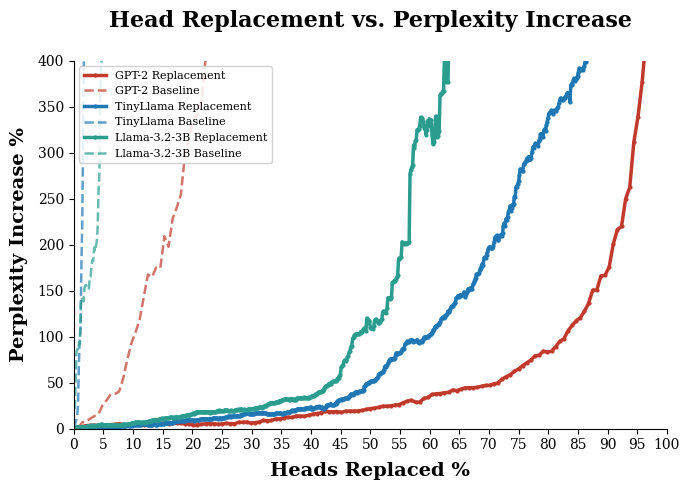

In [ ]:
MAX_INCREASE_SHOWN = 400  # clip y-axis; set None to show all

MODEL_PLOT_CONFIG = {
    'bert':      {'total_heads': 144, 'display': 'BERT',         'color': '#f0a868'},
    'gpt2':      {'total_heads': 144, 'display': 'GPT-2',        'color': '#c0392b'},
    'tinyllama': {'total_heads': 704, 'display': 'TinyLlama',    'color': '#1f77b4'},
    'llama3b':   {'total_heads': 672, 'display': 'Llama-3.2-3B', 'color': '#2a9d8f'},
}

fig, ax = plt.subplots(figsize=(7, 5))

for model_key, cfg in MODEL_PLOT_CONFIG.items():
    smart_path    = f'{RESULTS_DIR}/replacement_run/{model_key}_smart.csv'
    baseline_path = f'{RESULTS_DIR}/replacement_run/{model_key}_baseline.csv'

    if not os.path.exists(smart_path):
        print(f'[SKIP] {model_key}: no smart CSV found')
        continue

    smart_df = pd.read_csv(smart_path).sort_values('k')
    x_pct    = smart_df['k'].values / cfg['total_heads'] * 100
    smart_inc = smart_df['increase'].values

    ax.plot(x_pct, smart_inc,
            color=cfg['color'], linewidth=2.5, marker='o', markersize=2,
            label=f'{cfg["display"]} Replacement')

    if os.path.exists(baseline_path):
        baseline_df  = pd.read_csv(baseline_path).sort_values('k')
        bl_x         = baseline_df['k'].values / cfg['total_heads'] * 100
        bl_inc       = baseline_df['increase'].values
        ax.plot(bl_x, bl_inc,
                color=cfg['color'], linewidth=1.8, linestyle='--', alpha=0.7,
                label=f'{cfg["display"]} Baseline')


ax.set_xlabel('Heads Replaced %', fontweight='bold', fontsize=14, labelpad=7)
ax.set_ylabel('Perplexity Increase %', fontweight='bold', fontsize=14, labelpad=7)
ax.set_title('Head Replacement vs. Perplexity Increase\n', fontweight='bold', fontsize=16)
ax.set_xlim(0, 100)
ax.set_xticks(range(0, 101, 5))
if MAX_INCREASE_SHOWN is not None:
    ax.set_ylim(bottom=0, top=MAX_INCREASE_SHOWN)
ax.legend(framealpha=0.85, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/figure_4_3.pdf', bbox_inches='tight', dpi=600)
plt.savefig(f'{RESULTS_DIR}/plots/figure_5_perplexity.png', bbox_inches='tight', dpi=150)
plt.show()

[SKIP] bert: missing iou or smart CSV
GPT-2        Spearman r = -0.915, p = 0.0000
TinyLlama    Spearman r = -0.999, p = 0.0000
Llama-3.2-3B Spearman r = -0.999, p = 0.0000


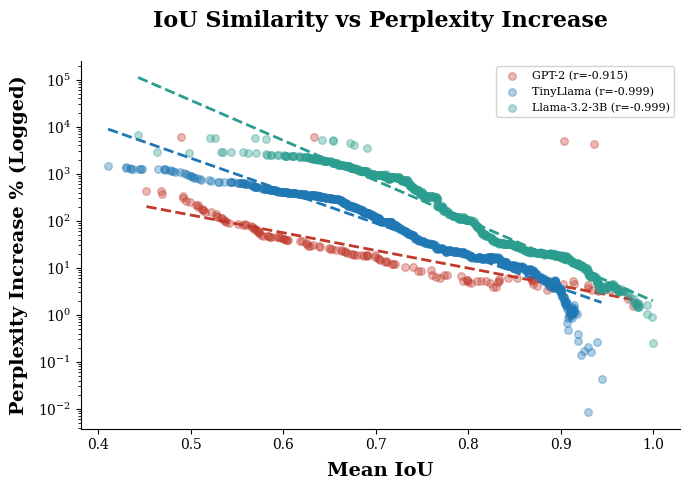

In [ ]:
import seaborn as sns
from scipy import stats

MODEL_PLOT_CONFIG = {
    'bert':      {'total_heads': 144, 'display': 'BERT',         'color': '#f0a868'},
    'gpt2':      {'total_heads': 144, 'display': 'GPT-2',        'color': '#c0392b'},
    'tinyllama': {'total_heads': 704, 'display': 'TinyLlama',    'color': '#1f77b4'},
    'llama3b':   {'total_heads': 672, 'display': 'Llama-3.2-3B', 'color': '#2a9d8f'},
}

def parse_head(h):
    try: return tuple(map(int, str(h).strip("()").split(",")))
    except: return (0, 0)

fig, ax = plt.subplots(figsize=(7, 5))

for model_key, cfg in MODEL_PLOT_CONFIG.items():
    iou_path   = f'{RESULTS_DIR}/iou_scores_{model_key}.csv'
    smart_path = f'{RESULTS_DIR}/replacement_run/{model_key}_smart.csv'

    if not os.path.exists(iou_path) or not os.path.exists(smart_path):
        print(f'[SKIP] {model_key}: missing iou or smart CSV')
        continue

    iou_df   = pd.read_csv(iou_path)
    smart_df = pd.read_csv(smart_path)

    mean_iou = (iou_df.groupby(['layer', 'head'])['iou_score']
                .max().reset_index()
                .rename(columns={'iou_score': 'mean_iou'}))

    smart_df['layer'] = smart_df['head'].apply(lambda h: parse_head(h)[0])
    smart_df['head_n'] = smart_df['head'].apply(lambda h: parse_head(h)[1])

    merged = smart_df.merge(mean_iou,
                            left_on=['layer', 'head_n'],
                            right_on=['layer', 'head'],
                            how='inner')
    merged = merged[merged['increase'] > 0].copy()
    merged['log_increase'] = np.log10(merged['increase'])

    if len(merged) < 5:
        print(f'[SKIP] {model_key}: too few points to fit')
        continue

    corr, pval = stats.spearmanr(merged['mean_iou'], merged['increase'])
    print(f"{cfg['display']:12s} Spearman r = {corr:.3f}, p = {pval:.4f}")

    ax.scatter(merged['mean_iou'], merged['increase'],
               alpha=0.35, color=cfg['color'], s=30, zorder=3,
               label=f'{cfg["display"]} (r={corr:.3f})')

    fit   = np.polyfit(merged['mean_iou'], merged['log_increase'], deg=1)
    x_fit = np.linspace(merged['mean_iou'].min(), merged['mean_iou'].max(), 200)
    y_fit = 10 ** np.polyval(fit, x_fit)
    ax.plot(x_fit, y_fit, color=cfg['color'], linewidth=2, linestyle='--')

ax.set_yscale('log')
ax.set_xlabel('Mean IoU', fontweight='bold', fontsize=14, labelpad=7)
ax.set_ylabel('Perplexity Increase % (Logged)', fontweight='bold', fontsize=14, labelpad=7)
ax.set_title('IoU Similarity vs Perplexity Increase\n', fontweight='bold', fontsize=16)
ax.legend(framealpha=0.85, fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/plots/figure_4_2_1.pdf', bbox_inches='tight', dpi=600)
plt.savefig(f'{RESULTS_DIR}/plots/figure_6_iou_vs_perplexity.png', bbox_inches='tight', dpi=150)
plt.show()

In [ ]:
# ── 18. load_model_and_tokenizer for evaluations ────────────────────────────
from transformers import GPT2LMHeadModel, GPT2Tokenizer

_model_cache = {}

def load_model_and_tokenizer(model_name):
    """Load and cache model+tokenizer for benchmark evaluation."""
    if model_name in _model_cache:
        return _model_cache[model_name]
    device = "cuda" if torch.cuda.is_available() else "cpu"
    if model_name == "gpt2":
        m = GPT2LMHeadModel.from_pretrained("gpt2").to(device).eval()
        t = GPT2Tokenizer.from_pretrained("gpt2")
        if t.pad_token is None: t.pad_token = t.eos_token
    else:
        raise NotImplementedError(f"Model {model_name} not yet supported in evaluations.")
    _model_cache[model_name] = (m, t)
    return m, t

print("load_model_and_tokenizer defined.")


load_model_and_tokenizer defined.


In [ ]:
# ── 19. Benchmark evaluation functions ───────────────────────────────
import json as _json
import torch.nn.functional as F
from datasets import load_dataset

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
N_SAMPLES = 200
REPLACEMENT_LEVELS = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00]
REPLACEMENT_LEVELS = [0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.75, 1.00]
TOTAL_HEADS_GPT2 = 144

RANDOM_BASELINES = {
    "HellaSwag":  0.25, "PIQA": 0.50, "SciQ": 0.25,
    "ARC-Easy":   0.25, "Social IQA": 0.33, "COPA": 0.50,
}

def score_completion(model, tokenizer, context, completion, relevant_layers=None, head_mapping=None):
    if relevant_layers and head_mapping:
        sent = context + " " + completion
        # Detect architecture by checking model type
        model_type = type(model).__name__
        for l in relevant_layers:
            if model_type == 'GPT2LMHeadModel':
                model.transformer.h[l].attn._current_sentence = sent
            else:  # LlamaForCausalLM, LlamaModel, etc.
                model.model.layers[l].self_attn._current_sentence = sent

    full  = context + " " + completion
    enc   = tokenizer(full,    return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    ctx_l = tokenizer(context, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)["input_ids"].shape[1]
    with torch.no_grad():
        logits = model(**enc).logits
    lp    = F.log_softmax(logits[0], dim=-1)
    ids   = enc["input_ids"][0]
    scores = [lp[i-1, ids[i]].item() for i in range(ctx_l, len(ids))]
    return float(np.mean(scores)) if scores else -np.inf


def evaluate_hellaswag(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    ds = load_dataset("Rowan/hellaswag", split="validation")
    correct = sum(
        int(np.argmax([score_completion(model, tokenizer, ex["ctx"], e,
                                        relevant_layers, head_mapping)
                       for e in ex["endings"]])) == int(ex["label"])
        for ex in ds.select(range(min(n, len(ds)))))
    return correct / min(n, len(ds))


def evaluate_piqa(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    ds = []
    with open(f"{DATA_DIR}/evaluations/piqa_val.jsonl") as f:
        for line in f:
            ds.append(_json.loads(line))
            if len(ds) >= n: break
    correct = sum(
        int(np.argmax([score_completion(model, tokenizer, ex["goal"], ex[f"sol{i+1}"],
                                        relevant_layers, head_mapping)
                       for i in range(2)])) == int(ex["label"])
        for ex in ds)
    return correct / len(ds)


def evaluate_sciq(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    ds = load_dataset("sciq", split="validation")
    correct = 0
    for ex in ds.select(range(min(n, len(ds)))):
        choices = [ex["distractor1"], ex["distractor2"], ex["distractor3"], ex["correct_answer"]]
        if int(np.argmax([score_completion(model, tokenizer, ex["question"], c,
                                           relevant_layers, head_mapping)
                          for c in choices])) == 3:
            correct += 1
    return correct / min(n, len(ds))


def evaluate_arc_easy(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    ds = load_dataset("allenai/ai2_arc", "ARC-Easy", split="validation")
    correct, count = 0, 0
    for ex in ds.select(range(min(n, len(ds)))):
        labels = ex["choices"]["label"]
        if ex["answerKey"] not in labels: continue
        idx = labels.index(ex["answerKey"])
        if int(np.argmax([score_completion(model, tokenizer, ex["question"], c,
                                           relevant_layers, head_mapping)
                          for c in ex["choices"]["text"]])) == idx:
            correct += 1
        count += 1
    return correct / count if count else 0.0


def evaluate_social_iqa(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    local = f"{DATA_DIR}/evaluations/socialIQa_v1.4/socialIQa_v1.4_dev.jsonl"
    ds, label_map = [], {"A": 0, "B": 1, "C": 2}
    with open(local, encoding="utf-8") as f:
        for line in f:
            ds.append(_json.loads(line))
            if len(ds) >= n: break
    correct, count = 0, 0
    for ex in ds:
        lbl = label_map.get(ex["correct"])
        if lbl is None: continue
        prompt = ex["context"].strip() + " " + ex["question"].strip()
        choices = [ex["answerA"], ex["answerB"], ex["answerC"]]
        if int(np.argmax([score_completion(model, tokenizer, prompt, c,
                                           relevant_layers, head_mapping)
                          for c in choices])) == lbl:
            correct += 1
        count += 1
    return correct / count if count else 0.0


def evaluate_copa(model, tokenizer, relevant_layers=None, head_mapping=None, n=200):
    ds = load_dataset("super_glue", "copa", split="validation")
    correct, count = 0, 0
    for ex in ds.select(range(min(n, len(ds)))):
        conn = "because" if ex["question"] == "cause" else "so"
        ctx  = ex["premise"].rstrip(".") + f" {conn}"
        if int(np.argmax([score_completion(model, tokenizer, ctx, ex[f"choice{i+1}"],
                                           relevant_layers, head_mapping)
                          for i in range(2)])) == ex["label"]:
            correct += 1
        count += 1
    return correct / count if count else 0.0


BENCHMARKS = [
    ("HellaSwag",  evaluate_hellaswag),
    ("PIQA",       evaluate_piqa),
    ("SciQ",       evaluate_sciq),
    ("ARC-Easy",   evaluate_arc_easy),
    ("Social IQA", evaluate_social_iqa),
    ("COPA",       evaluate_copa),
]

print(f"Benchmarks defined: {[b[0] for b in BENCHMARKS]}")


Benchmarks defined: ['HellaSwag', 'PIQA', 'SciQ', 'ARC-Easy', 'Social IQA', 'COPA']


In [ ]:
# ── 20. Build replaced model for a given replacement % ─────────────────

def build_replaced_model_gpt2(smart_df, replacement_pct):
    """Load GPT-2 with hooks replacing the top-k heads by IoU order."""
    target_heads = int(TOTAL_HEADS_GPT2 * replacement_pct)
    print(f"  Replacing {target_heads} heads ({int(replacement_pct*100)}%)")

    df = smart_df.sort_values("k").head(target_heads)
    head_mapping = {}
    for _, row in df.iterrows():
        ht = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[ht] = row["program"]

    relevant_layers = set(l for l, _ in head_mapping)
    model, tokenizer = load_model_and_tokenizer("gpt2")
    # fresh copy so we can re-hook at each replacement level
    model = GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval()

    def make_hook(lookup):
        def hook(module, inp, out):
            ctx = out[0]
            b, s, d = ctx.shape
            nh, hd = 12, d // 12
            m = ctx.view(b, s, nh, hd).clone()
            sent = getattr(module, "_current_sentence", None)
            if sent is None: return out
            for h in range(nh):
                key = (module.layer_id, h)
                if key in lookup:
                    prog = next((p for p in all_programs
                                 if p.__name__ == lookup[key]), None)
                    if prog:
                        try:
                            _, mat = prog(sent, tokenizer)
                            if mat is not None:
                                t = torch.tensor(mat).to(DEVICE, dtype=m.dtype)
                                m[:, :, h, :] = torch.matmul(t, m[:, :, h, :])
                        except Exception: pass
            return (m.view(b, s, d),) + out[1:]
        return hook

    handles = []
    for l in range(12):
        tgt = model.transformer.h[l].attn
        tgt.layer_id = l
        if l in relevant_layers:
            handles.append(tgt.register_forward_hook(make_hook(head_mapping)))

    return model, tokenizer, relevant_layers, handles, head_mapping

# ── 20b. Build replaced model — TinyLlama ─────────────────────────────────────
def build_replaced_model_tinyllama(smart_df, replacement_pct):
    MODEL_ID    = "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
    NUM_LAYERS  = 22
    NUM_HEADS   = 32
    HIDDEN_SIZE = 2048
    HEAD_DIM    = HIDDEN_SIZE // NUM_HEADS
    TOTAL_HEADS = 704

    target_heads = int(TOTAL_HEADS * replacement_pct)
    print(f"  TinyLlama: replacing {target_heads} heads ({int(replacement_pct*100)}%)")

    df = smart_df.sort_values("k").head(target_heads)
    head_mapping = {}
    for _, row in df.iterrows():
        ht = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[ht] = row["program"]

    relevant_layers = set(l for l, _ in head_mapping)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE).eval()

    def make_hook(lookup):
        def hook(module, inp, out):
            ctx = out[0].contiguous()
            b, s, _ = ctx.shape
            m = ctx.view(b, s, NUM_HEADS, HEAD_DIM).clone()
            sent = getattr(module, "_current_sentence", None)
            if sent is None: return out
            for h in range(NUM_HEADS):
                key = (module.layer_id, h)
                if key in lookup:
                    prog = next((p for p in MODEL_PROGRAMS["tinyllama"]
                                 if p.__name__ == lookup[key]), None)
                    if prog:
                        try:
                            _, mat = prog(sent, tokenizer)
                            if mat is not None:
                                t = torch.tensor(mat).to(DEVICE, dtype=m.dtype)
                                m[:, :, h, :] = torch.matmul(t, m[:, :, h, :])
                        except Exception: pass
            return (m.view(b, s, HIDDEN_SIZE),) + out[1:]
        return hook

    handles = []
    for l in range(NUM_LAYERS):
        tgt = model.model.layers[l].self_attn
        tgt.layer_id = l
        if l in relevant_layers:
            handles.append(tgt.register_forward_hook(make_hook(head_mapping)))

    return model, tokenizer, relevant_layers, handles, head_mapping


# ── 20c. Build replaced model — Llama-3B ──────────────────────────────────────
def build_replaced_model_llama3b(smart_df, replacement_pct):
    MODEL_ID    = "meta-llama/Llama-3.2-3B"
    NUM_LAYERS  = 28
    NUM_HEADS   = 24
    HIDDEN_SIZE = 3072
    HEAD_DIM    = HIDDEN_SIZE // NUM_HEADS  # 128
    TOTAL_HEADS = 672

    target_heads = int(TOTAL_HEADS * replacement_pct)
    print(f"  Llama-3B: replacing {target_heads} heads ({int(replacement_pct*100)}%)")

    df = smart_df.sort_values("k").head(target_heads)
    head_mapping = {}
    for _, row in df.iterrows():
        ht = tuple(map(int, str(row["head"]).strip("()").split(",")))
        head_mapping[ht] = row["program"]

    relevant_layers = set(l for l, _ in head_mapping)
    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.float16,
        device_map="auto",
        attn_implementation="eager",
    ).eval()

    def make_hook(lookup):
        def hook(module, inp, out):
            ctx = out[0].contiguous().float()
            b, s, _ = ctx.shape
            m = ctx.view(b, s, NUM_HEADS, HEAD_DIM).clone()
            sent = getattr(module, "_current_sentence", None)
            if sent is None: return out
            for h in range(NUM_HEADS):
                key = (module.layer_id, h)
                if key in lookup:
                    prog = next((p for p in MODEL_PROGRAMS["llama3b"]
                                 if p.__name__ == lookup[key]), None)
                    if prog:
                        try:
                            _, mat = prog(sent, tokenizer)
                            if mat is not None:
                                t = torch.tensor(mat, device=DEVICE,
                                                 dtype=m.dtype)
                                m[:, :, h, :] = torch.matmul(t, m[:, :, h, :])
                        except Exception: pass
            return (m.view(b, s, HIDDEN_SIZE).to(out[0].dtype),) + out[1:]
        return hook

    handles = []
    for l in range(NUM_LAYERS):
        tgt = model.model.layers[l].self_attn
        tgt.layer_id = l
        if l in relevant_layers:
            handles.append(tgt.register_forward_hook(make_hook(head_mapping)))

    return model, tokenizer, relevant_layers, handles, head_mapping

In [ ]:
# ── 21. Run evaluation sweep — all decoder models ─────────────────────────────
# For each model: baseline + REPLACEMENT_LEVELS on all 6 benchmarks.
# Skips if output CSV already exists. BERT excluded (encoder, no causal LM eval).

EVAL_CONFIG = {
    # "gpt2": {
    #     "build_fn":   build_replaced_model_gpt2,
    #     "load_fn":    lambda: (GPT2LMHeadModel.from_pretrained("gpt2").to(DEVICE).eval(),
    #                            GPT2Tokenizer.from_pretrained("gpt2")),
    #     "smart_csv":  f'{RESULTS_DIR}/replacement_run/gpt2_smart.csv',
    #     "out_csv":    f'{RESULTS_DIR}/evaluations/gpt2_downstream.csv',
    # },
    "tinyllama": {
        "build_fn":   build_replaced_model_tinyllama,
        "load_fn":    lambda: (AutoModelForCausalLM.from_pretrained(
                                   "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
                               ).to(DEVICE).eval(),
                               AutoTokenizer.from_pretrained(
                                   "TinyLlama/TinyLlama-1.1B-intermediate-step-1431k-3T"
                               )),
        "smart_csv":  f'{RESULTS_DIR}/replacement_run/tinyllama_smart.csv',
        "out_csv":    f'{RESULTS_DIR}/evaluations/tinyllama_downstream.csv',
    },
    # "llama3b": {
    #     "build_fn":   build_replaced_model_llama3b,
    #     "load_fn":    lambda: (AutoModelForCausalLM.from_pretrained(
    #                                "meta-llama/Llama-3.2-3B",
    #                                torch_dtype=torch.float16,
    #                                device_map="auto",
    #                                attn_implementation="eager",
    #                            ).eval(),
    #                            AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-3B")),
    #     "smart_csv":  f'{RESULTS_DIR}/replacement_run/llama3b_smart.csv',
    #     "out_csv":    f'{RESULTS_DIR}/evaluations/llama3b_downstream.csv',
    # },
}

os.makedirs(f'{RESULTS_DIR}/evaluations', exist_ok=True)
all_downstream = []

for model_key, cfg in EVAL_CONFIG.items():
    if os.path.exists(cfg["out_csv"]):
        print(f"[SKIP] {model_key}: loading existing {cfg['out_csv']}")
        df_existing = pd.read_csv(cfg["out_csv"])
        all_downstream.append(df_existing)
        continue

    if not os.path.exists(cfg["smart_csv"]):
        print(f"[SKIP] {model_key}: no smart CSV at {cfg['smart_csv']}")
        continue

    smart_df = pd.read_csv(cfg["smart_csv"]).sort_values("k").reset_index(drop=True)
    print(f"\n{'='*60}")
    print(f"Evaluating {model_key.upper()} — {len(smart_df)} replacement steps")
    print(f"{'='*60}")

    model_results = []

    # ── Baseline ──────────────────────────────────────────────────────────────
    # print("\n── Baseline (no replacement) ──")
    # base_model, base_tok = cfg["load_fn"]()
    # if base_tok.pad_token is None:
    #     base_tok.pad_token = base_tok.eos_token
    # baseline_row = {"model": model_key, "replacement_pct": 0}
    # for name, fn in BENCHMARKS:
    #     print(f"  {name}...")
    #     baseline_row[name] = fn(base_model, base_tok, n=N_SAMPLES)
    #     print(f"    {baseline_row[name]:.4f}")
    # del base_model; torch.cuda.empty_cache()
    # model_results.append(baseline_row)

    # ── Replacement levels ────────────────────────────────────────────────────
    for pct in REPLACEMENT_LEVELS:
        print(f"\n── {int(pct*100)}% replacement ──")
        model, tokenizer, rel_layers, handles, hmap = cfg["build_fn"](smart_df, pct)
        if tokenizer.pad_token is None:
            tokenizer.pad_token = tokenizer.eos_token
        row = {"model": model_key, "replacement_pct": int(pct * 100)}
        for name, fn in BENCHMARKS:
            print(f"  {name}...")
            row[name] = fn(model, tokenizer, rel_layers, hmap, n=N_SAMPLES)
            print(f"    {row[name]:.4f}")
        for h in handles: h.remove()
        del model; torch.cuda.empty_cache()
        model_results.append(row)

    df_model = pd.DataFrame(model_results)
    df_model.to_csv(cfg["out_csv"], index=False)
    print(f"\nSaved → {cfg['out_csv']}")
    print(df_model.to_string())
    all_downstream.append(df_model)

# Combine all results
if all_downstream:
    combined_df = pd.concat(all_downstream, ignore_index=True)
    combined_df.to_csv(f'{RESULTS_DIR}/evaluations/all_downstream.csv', index=False)
    print(f"\n[DONE] Combined results saved → {RESULTS_DIR}/evaluations/all_downstream.csv")
    print(combined_df.groupby("model")[
        [b[0] for b in BENCHMARKS]].mean().round(3).to_string())


Evaluating TINYLLAMA — 704 replacement steps

── 15% replacement ──
  TinyLlama: replacing 105 heads (15%)


config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/776 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  HellaSwag...
    0.4500
  PIQA...
    0.7000
  SciQ...
    0.5200
  ARC-Easy...
    0.4900
  Social IQA...
    0.3900
  COPA...
    0.6400

── 25% replacement ──
  TinyLlama: replacing 176 heads (25%)


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

  HellaSwag...
    0.4500
  PIQA...
    0.6850
  SciQ...


KeyboardInterrupt: 

In [ ]:

# ============================================================
# Evaluating TINYLLAMA — 704 replacement steps
# ============================================================

# ── 15% replacement ──
#   TinyLlama: replacing 105 heads (15%)
# config.json: 100% 560/560 [00:00<00:00, 27.8kB/s]tokenizer_config.json: 100% 776/776 [00:00<00:00, 40.7kB/s]tokenizer.json:  1.84M/? [00:00<00:00, 35.9MB/s]tokenizer.model: 100% 500k/500k [00:00<00:00, 2.49MB/s]special_tokens_map.json: 100% 414/414 [00:00<00:00, 41.0kB/s]model.safetensors: 100% 4.40G/4.40G [00:39<00:00, 119MB/s]Loading weights: 100% 201/201 [00:00<00:00, 292.58it/s, Materializing param=model.norm.weight]generation_config.json: 100% 129/129 [00:00<00:00, 7.27kB/s]  HellaSwag...
# README.md:  7.02k/? [00:00<00:00, 657kB/s]data/train-00000-of-00001.parquet: 100% 24.4M/24.4M [00:00<00:00, 122MB/s]data/test-00000-of-00001.parquet: 100% 6.11M/6.11M [00:00<00:00, 26.0MB/s]data/validation-00000-of-00001.parquet: 100% 6.32M/6.32M [00:00<00:00, 31.6MB/s]Generating train split: 100% 39905/39905 [00:00<00:00, 127474.11 examples/s]Generating test split: 100% 10003/10003 [00:00<00:00, 133168.78 examples/s]Generating validation split: 100% 10042/10042 [00:00<00:00, 122826.94 examples/s]    0.4600
#   PIQA...
#     0.6900
#   SciQ...
# README.md:  7.02k/? [00:00<00:00, 560kB/s]data/train-00000-of-00001.parquet: 100% 3.99M/3.99M [00:00<00:00, 19.9MB/s]data/validation-00000-of-00001.parquet: 100% 339k/339k [00:00<00:00, 1.50MB/s]data/test-00000-of-00001.parquet: 100% 343k/343k [00:00<00:00, 1.51MB/s]Generating train split: 100% 11679/11679 [00:00<00:00, 158428.94 examples/s]Generating validation split: 100% 1000/1000 [00:00<00:00, 39501.83 examples/s]Generating test split: 100% 1000/1000 [00:00<00:00, 32872.01 examples/s]    0.5300
#   ARC-Easy...
# README.md:  9.00k/? [00:00<00:00, 800kB/s]ARC-Easy/train-00000-of-00001.parquet: 100% 331k/331k [00:00<00:00, 1.65MB/s]ARC-Easy/test-00000-of-00001.parquet: 100% 346k/346k [00:00<00:00, 1.54MB/s]ARC-Easy/validation-00000-of-00001.parqu(…): 100% 86.1k/86.1k [00:00<00:00, 376kB/s]Generating train split: 100% 2251/2251 [00:00<00:00, 74980.37 examples/s]Generating test split: 100% 2376/2376 [00:00<00:00, 72091.69 examples/s]Generating validation split: 100% 570/570 [00:00<00:00, 26305.84 examples/s]    0.4900
#   Social IQA...
#     0.3800
#   COPA...
# README.md:  19.7k/? [00:00<00:00, 1.75MB/s]copa/train-00000-of-00001.parquet: 100% 33.9k/33.9k [00:00<00:00, 169kB/s]copa/validation-00000-of-00001.parquet: 100% 12.0k/12.0k [00:00<00:00, 59.8kB/s]copa/test-00000-of-00001.parquet: 100% 40.2k/40.2k [00:00<00:00, 168kB/s]Generating train split: 100% 400/400 [00:00<00:00, 20703.16 examples/s]Generating validation split: 100% 100/100 [00:00<00:00, 5874.05 examples/s]Generating test split: 100% 500/500 [00:00<00:00, 19522.92 examples/s]    0.6200

# ── 20% replacement ──
#   TinyLlama: replacing 140 heads (20%)
# Loading weights: 100% 201/201 [00:00<00:00, 504.25it/s, Materializing param=model.norm.weight]  HellaSwag...
#     0.4500
#   PIQA...
#     0.7000
#   SciQ...
#     0.5200
#   ARC-Easy...
#     0.4900
#   Social IQA...
#     0.3900
#   COPA...
#     0.6400

# ── 25% replacement ──
#   TinyLlama: replacing 176 heads (25%)
# Loading weights: 100% 201/201 [00:00<00:00, 559.81it/s, Materializing param=model.norm.weight]  HellaSwag...
#     0.4500
#   PIQA...
#     0.6850
#   SciQ...
# ---------------------------------------------------------------------------
# KeyboardInterrupt                         Traceback (most recent call last)
# /tmp/ipykernel_6060/292808912.py in <cell line: 0>()
#      79         for name, fn in BENCHMARKS:
#      80             print(f"  {name}...")
# ---> 81             row[name] = fn(model, tokenizer, rel_layers, hmap, n=N_SAMPLES)
#      82             print(f"    {row[name]:.4f}")
#      83         for h in handles: h.remove()

# 22 frames/tmp/ipykernel_6060/3718361608.py in evaluate_sciq(model, tokenizer, relevant_layers, head_mapping, n)
#      66     for ex in ds.select(range(min(n, len(ds)))):
#      67         choices = [ex["distractor1"], ex["distractor2"], ex["distractor3"], ex["correct_answer"]]
# ---> 68         if int(np.argmax([score_completion(model, tokenizer, ex["question"], c,
#      69                                            relevant_layers, head_mapping)
#      70                           for c in choices])) == 3:

# /tmp/ipykernel_6060/3718361608.py in score_completion(model, tokenizer, context, completion, relevant_layers, head_mapping)
#      30     ctx_l = tokenizer(context, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)["input_ids"].shape[1]
#      31     with torch.no_grad():
# ---> 32         logits = model(**enc).logits
#      33     lp    = F.log_softmax(logits[0], dim=-1)
#      34     ids   = enc["input_ids"][0]

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _wrapped_call_impl(self, *args, **kwargs)
#    1774             return self._compiled_call_impl(*args, **kwargs)  # type: ignore[misc]
#    1775         else:
# -> 1776             return self._call_impl(*args, **kwargs)
#    1777
#    1778     # torchrec tests the code consistency with the following code

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _call_impl(self, *args, **kwargs)
#    1785                 or _global_backward_pre_hooks or _global_backward_hooks
#    1786                 or _global_forward_hooks or _global_forward_pre_hooks):
# -> 1787             return forward_call(*args, **kwargs)
#    1788
#    1789         result = None

# /usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py in wrapper(self, *args, **kwargs)
#     833         if return_dict_passed is not None:
#     834             return_dict = return_dict_passed
# --> 835         output = func(self, *args, **kwargs)
#     836         if not return_dict and not isinstance(output, tuple):
#     837             output = output.to_tuple()

# /usr/local/lib/python3.12/dist-packages/transformers/models/llama/modeling_llama.py in forward(self, input_ids, attention_mask, position_ids, past_key_values, inputs_embeds, labels, use_cache, cache_position, logits_to_keep, **kwargs)
#     484         "Hey, are you conscious? Can you talk to me?\nI'm not conscious, but I can talk to you."
#     485         ```"""
# --> 486         outputs: BaseModelOutputWithPast = self.model(
#     487             input_ids=input_ids,
#     488             attention_mask=attention_mask,

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _wrapped_call_impl(self, *args, **kwargs)
#    1774             return self._compiled_call_impl(*args, **kwargs)  # type: ignore[misc]
#    1775         else:
# -> 1776             return self._call_impl(*args, **kwargs)
#    1777
#    1778     # torchrec tests the code consistency with the following code

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _call_impl(self, *args, **kwargs)
#    1785                 or _global_backward_pre_hooks or _global_backward_hooks
#    1786                 or _global_forward_hooks or _global_forward_pre_hooks):
# -> 1787             return forward_call(*args, **kwargs)
#    1788
#    1789         result = None

# /usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py in wrapper(self, *args, **kwargs)
#    1000                         outputs = func(self, *args, **kwargs)
#    1001                 else:
# -> 1002                     outputs = func(self, *args, **kwargs)
#    1003             except TypeError as original_exception:
#    1004                 # If we get a TypeError, it's possible that the model is not receiving the recordable kwargs correctly.

# /usr/local/lib/python3.12/dist-packages/transformers/models/llama/modeling_llama.py in forward(self, input_ids, attention_mask, position_ids, past_key_values, inputs_embeds, cache_position, use_cache, **kwargs)
#     419
#     420         for decoder_layer in self.layers[: self.config.num_hidden_layers]:
# --> 421             hidden_states = decoder_layer(
#     422                 hidden_states,
#     423                 attention_mask=causal_mask,

# /usr/local/lib/python3.12/dist-packages/transformers/modeling_layers.py in __call__(self, *args, **kwargs)
#      91
#      92             return self._gradient_checkpointing_func(partial(super().__call__, **kwargs), *args)
# ---> 93         return super().__call__(*args, **kwargs)
#      94
#      95

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _wrapped_call_impl(self, *args, **kwargs)
#    1774             return self._compiled_call_impl(*args, **kwargs)  # type: ignore[misc]
#    1775         else:
# -> 1776             return self._call_impl(*args, **kwargs)
#    1777
#    1778     # torchrec tests the code consistency with the following code

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _call_impl(self, *args, **kwargs)
#    1785                 or _global_backward_pre_hooks or _global_backward_hooks
#    1786                 or _global_forward_hooks or _global_forward_pre_hooks):
# -> 1787             return forward_call(*args, **kwargs)
#    1788
#    1789         result = None

# /usr/local/lib/python3.12/dist-packages/transformers/models/llama/modeling_llama.py in forward(self, hidden_states, attention_mask, position_ids, past_key_values, use_cache, cache_position, position_embeddings, **kwargs)
#     318         hidden_states = self.input_layernorm(hidden_states)
#     319         # Self Attention
# --> 320         hidden_states, _ = self.self_attn(
#     321             hidden_states=hidden_states,
#     322             attention_mask=attention_mask,

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _wrapped_call_impl(self, *args, **kwargs)
#    1774             return self._compiled_call_impl(*args, **kwargs)  # type: ignore[misc]
#    1775         else:
# -> 1776             return self._call_impl(*args, **kwargs)
#    1777
#    1778     # torchrec tests the code consistency with the following code

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in _call_impl(self, *args, **kwargs)
#    1880
#    1881         try:
# -> 1882             return inner()
#    1883         except Exception:
#    1884             # run always called hooks if they have not already been run

# /usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py in inner()
#    1841                         hook_result = hook(self, args, kwargs, result)
#    1842                     else:
# -> 1843                         hook_result = hook(self, args, result)
#    1844
#    1845                     if hook_result is not None:

# /tmp/ipykernel_6060/492681485.py in hook(module, inp, out)
#      87                     if prog:
#      88                         try:
# ---> 89                             _, mat = prog(sent, tokenizer)
#      90                             if mat is not None:
#      91                                 t = torch.tensor(mat).to(DEVICE, dtype=m.dtype)

# /content/drive/MyDrive/LLM-Interpretability/data/tinyllama_programs.py in prog_L1H30(sentence, tokenizer)
#   27752             # Check for specific patterns like "stay" -> "and", "grow" -> "to"
#   27753             doc = spacy_parse(sentence)
# > 27754             token_to_spacy = _align_to_spacy(sentence, tokens)
#   27755
#   27756             if token_to_spacy[i] and token_to_spacy[i-1]:

# /content/drive/MyDrive/LLM-Interpretability/data/tinyllama_programs.py in _align_to_spacy(sentence, tokens)
#      21
#      22 def _align_to_spacy(sentence: str, tokens: list) -> list:
# ---> 23     doc = _get_nlp()(sentence)
#      24     spans, pos = [], 0
#      25     for t in tokens:

# /usr/local/lib/python3.12/dist-packages/spacy/language.py in __call__(self, text, disable, component_cfg)
#    1051                 error_handler = proc.get_error_handler()
#    1052             try:
# -> 1053                 doc = proc(doc, **component_cfg.get(name, {}))  # type: ignore[call-arg]
#    1054             except KeyError as e:
#    1055                 # This typically happens if a component is not initialized

# /usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py in __call__(self, doc)
#     129         error_handler = self.get_error_handler()
#     130         try:
# --> 131             matches = self.match(doc)
#     132             self.set_annotations(doc, matches)
#     133             return doc

# /usr/local/lib/python3.12/dist-packages/spacy/pipeline/attributeruler.py in match(self, doc)
#     136
#     137     def match(self, doc: Doc):
# --> 138         matches = self.matcher(doc, allow_missing=True, as_spans=False)
#     139         # Sort by the attribute ID, so that later rules have precedence
#     140         matches = [

# KeyboardInterrupt:

In [ ]:

# ============================================================
# Evaluating TINYLLAMA — 704 replacement steps
# ============================================================

# ── 5% replacement ──
#   TinyLlama: replacing 35 heads (5%)
# Loading weights: 100% 201/201 [00:00<00:00, 457.99it/s, Materializing param=model.norm.weight]  HellaSwag...
# README.md:  7.02k/? [00:00<00:00, 416kB/s]data/train-00000-of-00001.parquet: 100% 24.4M/24.4M [00:00<00:00, 121MB/s]data/test-00000-of-00001.parquet: 100% 6.11M/6.11M [00:00<00:00, 26.6MB/s]data/validation-00000-of-00001.parquet: 100% 6.32M/6.32M [00:00<00:00, 31.6MB/s]Generating train split: 100% 39905/39905 [00:00<00:00, 137552.38 examples/s]Generating test split: 100% 10003/10003 [00:00<00:00, 134773.37 examples/s]Generating validation split: 100% 10042/10042 [00:00<00:00, 99330.48 examples/s]    0.4700
#   PIQA...
#     0.7100
#   SciQ...
# README.md:  7.02k/? [00:00<00:00, 623kB/s]data/train-00000-of-00001.parquet: 100% 3.99M/3.99M [00:00<00:00, 19.9MB/s]data/validation-00000-of-00001.parquet: 100% 339k/339k [00:00<00:00, 1.38MB/s]data/test-00000-of-00001.parquet: 100% 343k/343k [00:00<00:00, 1.43MB/s]Generating train split: 100% 11679/11679 [00:00<00:00, 120339.80 examples/s]Generating validation split: 100% 1000/1000 [00:00<00:00, 34553.16 examples/s]Generating test split: 100% 1000/1000 [00:00<00:00, 26475.51 examples/s]    0.5150
#   ARC-Easy...
# README.md:  9.00k/? [00:00<00:00, 603kB/s]ARC-Easy/train-00000-of-00001.parquet: 100% 331k/331k [00:04<00:00, 1.65MB/s]ARC-Easy/test-00000-of-00001.parquet: 100% 346k/346k [00:00<00:00, 1.50MB/s]ARC-Easy/validation-00000-of-00001.parqu(…): 100% 86.1k/86.1k [00:00<00:00, 373kB/s]Generating train split: 100% 2251/2251 [00:00<00:00, 71648.26 examples/s]Generating test split: 100% 2376/2376 [00:00<00:00, 90999.02 examples/s]Generating validation split: 100% 570/570 [00:00<00:00, 27106.97 examples/s]    0.5100
#   Social IQA...
#     0.4000
#   COPA...
# README.md:  19.7k/? [00:00<00:00, 1.72MB/s]copa/train-00000-of-00001.parquet: 100% 33.9k/33.9k [00:00<00:00, 92.7kB/s]copa/validation-00000-of-00001.parquet: 100% 12.0k/12.0k [00:00<00:00, 50.9kB/s]copa/test-00000-of-00001.parquet: 100% 40.2k/40.2k [00:00<00:00, 175kB/s]Generating train split: 100% 400/400 [00:00<00:00, 22147.26 examples/s]Generating validation split: 100% 100/100 [00:00<00:00, 7348.63 examples/s]Generating test split: 100% 500/500 [00:00<00:00, 33786.89 examples/s]    0.6300

# ── 10% replacement ──
#   TinyLlama: replacing 70 heads (10%)
# Loading weights: 100% 201/201 [00:00<00:00, 639.35it/s, Materializing param=model.norm.weight]  HellaSwag...
#     0.4650
#   PIQA...
#     0.6900
#   SciQ...
#     0.5100
#   ARC-Easy...
#     0.5050
#   Social IQA...
#     0.4000
#   COPA...
#     0.6300

# ── 15% replacement ──
#   TinyLlama: replacing 105 heads (15%)
# Loading weights: 100% 201/201 [00:00<00:00, 706.49it/s, Materializing param=model.norm.weight]  HellaSwag...
#     0.4600
#   PIQA...
#     0.6900
#   SciQ...
#     0.5300
#   ARC-Easy...


In [ ]:
all_results = [
    {'model': 'gpt2', 'replacement_pct': 0, 'HellaSwag': 0.31, 'PIQA': 0.635, 'SciQ': 0.475, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct': 5, 'HellaSwag': 0.32, 'PIQA': 0.63, 'SciQ': 0.48, 'ARC-Easy': 0.36, 'Social IQA': 0.41, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct': 10, 'HellaSwag': 0.325, 'PIQA': 0.615, 'SciQ': 0.455, 'ARC-Easy': 0.35, 'Social IQA': 0.415, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct': 15, 'HellaSwag': 0.34, 'PIQA': 0.62, 'SciQ': 0.45, 'ARC-Easy': 0.345, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct': 20, 'HellaSwag': 0.34, 'PIQA': 0.63, 'SciQ': 0.45, 'ARC-Easy': 0.34, 'Social IQA': 0.405, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct': 25, 'HellaSwag': 0.33, 'PIQA': 0.635, 'SciQ': 0.435, 'ARC-Easy': 0.36, 'Social IQA': 0.42, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct': 30, 'HellaSwag': 0.315, 'PIQA': 0.61, 'SciQ': 0.43, 'ARC-Easy': 0.35, 'Social IQA': 0.4, 'COPA': 0.55},
    {'model': 'gpt2', 'replacement_pct': 40, 'HellaSwag': 0.3, 'PIQA': 0.605, 'SciQ': 0.395, 'ARC-Easy': 0.32, 'Social IQA': 0.38, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct': 50, 'HellaSwag': 0.305, 'PIQA': 0.615, 'SciQ': 0.385, 'ARC-Easy': 0.33, 'Social IQA': 0.38, 'COPA': 0.56},
    {'model': 'gpt2', 'replacement_pct': 75, 'HellaSwag': 0.275, 'PIQA': 0.585, 'SciQ': 0.34, 'ARC-Easy': 0.29, 'Social IQA': 0.385, 'COPA': 0.54},
    {'model': 'gpt2', 'replacement_pct': 100, 'HellaSwag': 0.255, 'PIQA': 0.525, 'SciQ': 0.315, 'ARC-Easy': 0.28, 'Social IQA': 0.375, 'COPA': 0.5}
]

results_df = pd.DataFrame(all_results)
os.makedirs(f'{RESULTS_DIR}/evaluations', exist_ok=True)
results_df.to_csv(f'{RESULTS_DIR}/evaluations/gpt2_downstream.csv', index=False)

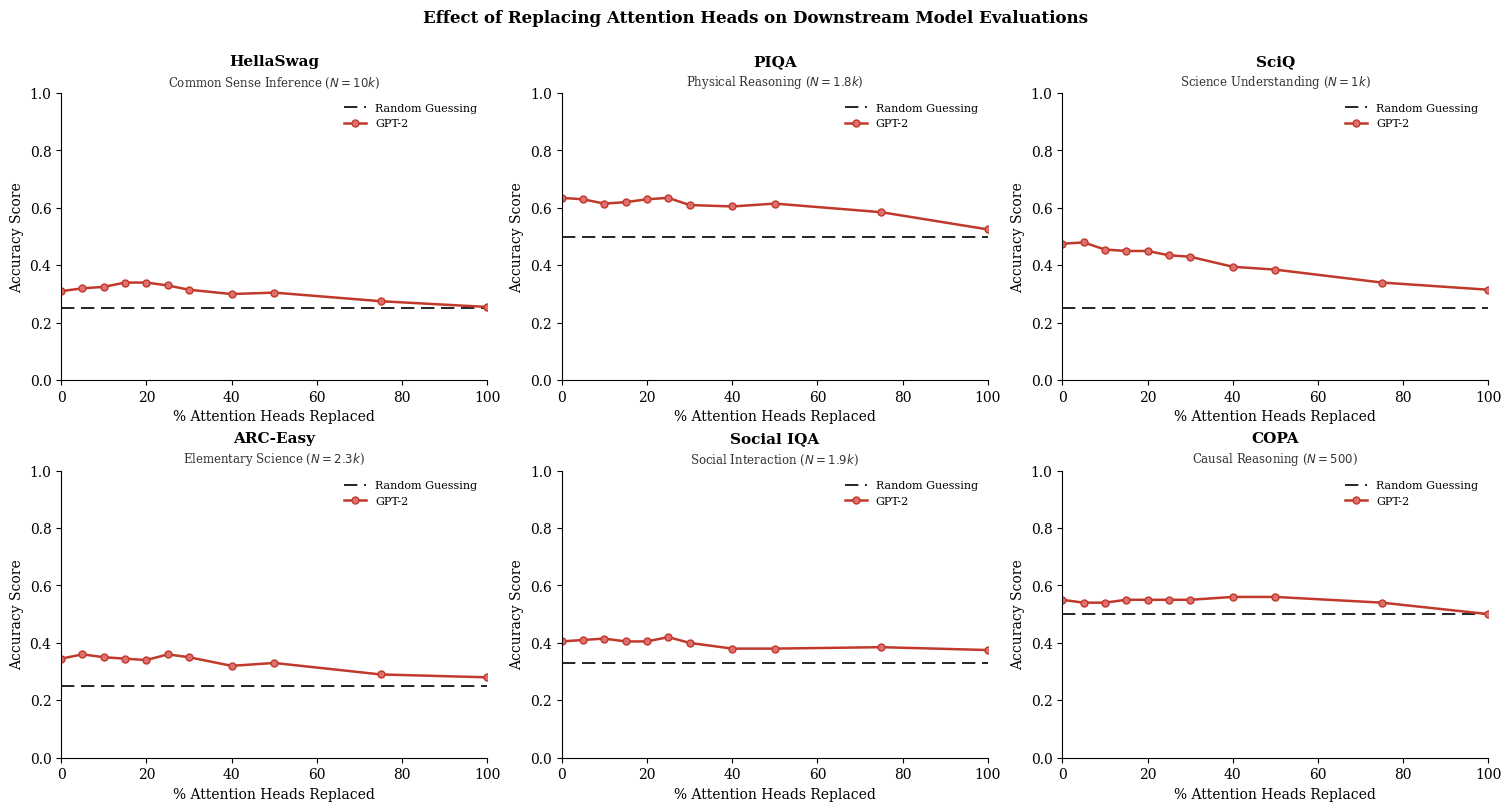

[DONE] Figure 7 saved.


In [ ]:
# ── 22. Figure 7 — Downstream task accuracy vs heads replaced ────────────────
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "serif"

META = {
    "HellaSwag":  {"desc": "Common Sense Inference",  "n": "10k"},
    "PIQA":       {"desc": "Physical Reasoning",       "n": "1.8k"},
    "SciQ":       {"desc": "Science Understanding",    "n": "1k"},
    "ARC-Easy":   {"desc": "Elementary Science",       "n": "2.3k"},
    "Social IQA": {"desc": "Social Interaction",       "n": "1.9k"},
    "COPA":       {"desc": "Causal Reasoning",         "n": "500"},
}
GPT2_COLOR = {"line": "#c0392b", "box": "#e07070"}

fig, axes = plt.subplots(2, 3, figsize=(15, 8), constrained_layout=True)

for ax, (metric, meta) in zip(axes.flatten(), META.items()):
    baseline = RANDOM_BASELINES[metric]
    ax.axhline(baseline, color="black", linestyle="--", dashes=(8, 4),
               linewidth=1.2, label="Random Guessing")

    if metric in results_df.columns:
        sub = results_df.sort_values("replacement_pct")
        ax.plot(sub["replacement_pct"], sub[metric],
                marker="o", linewidth=1.8, markersize=5,
                color=GPT2_COLOR["line"],
                markerfacecolor=GPT2_COLOR["box"],
                label="GPT-2")

    ax.set_title(metric, fontweight="bold", fontsize=11, pad=20)
    ax.text(0.5, 1.01, f'{meta["desc"]} ($N={meta["n"]}$)',
            transform=ax.transAxes, ha="center", va="bottom",
            fontsize=8.5, color="#333333")
    ax.set_ylim(0, 1.0)
    ax.set_xlim(0, 100)
    ax.set_xticks(range(0, 101, 20))
    ax.legend(fontsize=8, frameon=False)
    ax.set_xlabel("% Attention Heads Replaced", fontsize=10)
    ax.set_ylabel("Accuracy Score", fontsize=10)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.suptitle("Effect of Replacing Attention Heads on Downstream Model Evaluations\n",
             fontsize=12, fontweight="bold")
plt.savefig(f'{RESULTS_DIR}/plots/figure_7_downstream.pdf', bbox_inches="tight", dpi=150)
plt.savefig(f'{RESULTS_DIR}/plots/figure_7_downstream.png', bbox_inches="tight", dpi=150)
plt.show()
print("[DONE] Figure 7 saved.")
